In [1]:
import glob
import re
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.dates as mdates
# geopandas extends pandas to handle geospatial data and perform operations on geographic shapes.
import geopandas as gpd
# matplotlib.colors provides tools to define and manipulate colormaps for visualizations.
import matplotlib.colors as mcolors
# ListedColormap allows the creation of custom colormaps for visualizations.
from matplotlib.colors import ListedColormap
from pathlib import Path
from typing import List
from matplotlib.patches import Patch
from scipy.signal import find_peaks
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from scipy.optimize import nnls
#import matplotlib.colormaps as cm
import matplotlib.markers as mmarkers
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
# For PDPs
from sklearn.inspection import PartialDependenceDisplay
from sklearn.preprocessing import OneHotEncoder

In [2]:


def collect_files(base_dir: str, dirs: List[str], subpath: str, pattern: str, exclude: str = None) -> List[str]:
    """
    Collects files matching a pattern from specified subdirectories.

    Parameters:
        base_dir (str): Base directory containing all subdirectories.
        dirs (List[str]): List of subdirectory names.
        subpath (str): Relative path inside each subdirectory where files are located.
        pattern (str): Glob pattern to match files.
        exclude (str, optional): String pattern to exclude from results.

    Returns:
        List[str]: Sorted list of matching file paths as strings.
    """
    all_files = []
    for d in dirs:
        search_path = Path(base_dir) / d / subpath / pattern
        files = sorted(search_path.parent.glob(search_path.name))
        if exclude:
            files = [f for f in files if exclude not in f.name]
        all_files.extend([str(f) for f in files])
    return all_files

# Base directory and subdirectories
base_dir = "/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012"
dirs = [
    "b732-sep-15", "b733-sep-16", 
    "b734-sep-18", "b735-sep-19", "b736-sep-19", "b737-sep-20", "b738-sep-22", 
    "b739-sep-23", "b742-sep-27", "b743-sep-27", 
    "b744-sep-28", "b745-sep-28", "b746-sep-29", "b748-oct-02", 
    "b749-oct-03"
]

# Collect files
core_processed_files = collect_files(base_dir, dirs, "core_processed", "core_faam*r1*.nc", exclude="_1hz")
dry_neph_files = collect_files(base_dir, dirs, "mo-non-core", "metoffice*neph1*.nc")
flight_sum_files = collect_files(base_dir, dirs, ".", "flight-sum*.txt")
sp2_files = collect_files(base_dir, dirs, "non-core", "man-sp2*.na")
ams_files = collect_files(base_dir, dirs, "non-core", "man-ams*.na")
lidar_files = collect_files(base_dir, dirs, "non-core", "met*.nc")
core_processed_files_cloud = collect_files(base_dir, dirs, "core_processed", "core-cloud*r0*.nc")
#core-cloud-phy_faam_20120920_v500_r0_b737#

# Example: print or pass them into other analysis
# print(core_processed_files)


In [3]:
# Function to extract flight number (e.g., "b734") from a file path
def extract_flight_number(file_path):
    match = re.search(r'b\d{3}', file_path)
    return match.group(0) if match else None  # Returns None if no match

# Get flight numbers for each dataset
flights_core = {extract_flight_number(f) for f in core_processed_files}
flights_ams = {extract_flight_number(f) for f in dry_neph_files}
flights_sp2 = {extract_flight_number(f) for f in sp2_files}
flights_neph = {extract_flight_number(f) for f in ams_files}
flights_cloud = {extract_flight_number(f) for f in core_processed_files_cloud}

# Find flights that are in all three datasets
common_flights = flights_core & flights_ams & flights_sp2 & flights_neph & flights_cloud # Set intersection

# Filter the file lists to include only matching flights
filtered_core = [f for f in core_processed_files if extract_flight_number(f) in common_flights]
filtered_ams = [f for f in ams_files if extract_flight_number(f) in common_flights]
filtered_sp2 = [f for f in sp2_files if extract_flight_number(f) in common_flights]
filtered_neph = [f for f in dry_neph_files if extract_flight_number(f) in common_flights]
filtered_cloud = [f for f in core_processed_files_cloud if extract_flight_number(f) in common_flights]

# Print the results
print(f"Common flights: {sorted(common_flights)}")
print(f"Filtered Core files: {len(filtered_core)}")
print(f"Filtered AMS files: {len(filtered_ams)}")
print(f"Filtered SP2 files: {len(filtered_sp2)}")
print(f"Filtered Neph files: {len(filtered_neph)}")
print(f"Filtered Cloud files: {len(filtered_cloud)}")

Common flights: ['b734', 'b737', 'b739', 'b742', 'b743', 'b744', 'b745', 'b746', 'b748', 'b749']
Filtered Core files: 10
Filtered AMS files: 10
Filtered SP2 files: 10
Filtered Neph files: 10
Filtered Cloud files: 10


In [4]:
def geometric_mean_diameter(D_lower, D_upper, concentrations):
    """
    Compute geometric mean diameter (µm) from channel boundaries and concentrations.
    """
    # Bin midpoints in log-space
    D_mid = np.sqrt(D_lower * D_upper)

    # Ensure concentrations is numpy array and mask invalids
    concentrations = np.array(concentrations, dtype=float)
    mask = (concentrations > 0) & (concentrations != 9999)

    if not np.any(mask):
        #print('retornou')
        return np.nan  # no valid data

    conc = concentrations[mask]
    D_mid = D_mid[mask]

    # Weighted geometric mean
    log_Dg = np.nansum(conc * np.log(D_mid)) / np.nansum(conc)
    return np.exp(log_Dg)

In [5]:
def convert_time_to_datetime_sp2(dsf, start_date_str):
    """
    Convert the 'Time_start_UTC' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_start_UTC'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_UTC"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf
    
def convert_time_to_datetime_ams(dsf, start_date_str):
    """
    Convert the 'Time_start_UTC' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_start_UTC'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_start_UTC"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf
    
def convert_time_to_datetime_neph(dsf, start_date_str):
    
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")

    key_options = ["neph_spm", "NEPH_SPM"]  # Possible variations of the key
    matching_key = next((key for key in key_options if key in dsf), None)
    
    if matching_key:
        time_seconds_t = dsf[matching_key].values
    else:
        raise KeyError("Variable 'neph_spm' not found in dataset.")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    #time_seconds = dsf["neph_spm"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds_t])

    dsf = dsf.assign_coords(time=dsf['neph_spm'])
    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))
    #dsf["Times"] = (("time",), datetime_values)
    #dsf["datetime"] = (("time",), datetime_values)
    #dsf = dsf.set_coords('neph_spm')

    return dsf

In [6]:
def dataset_sp2_ams_neph(file_path_sp2,file_path_ams,file_path_neph):

    with open(file_path_sp2, "rb") as f:
        lines_sp2 = f.readlines()  # Read the first 100 bytes
    with open(file_path_ams, "rb") as f:
        lines_ams = f.readlines()  # Read the first 100 bytes
        
    metadata_lines_sp2 = lines_sp2[:39]  # 39 lines are metadata
    header_line_sp2 = metadata_lines_sp2[38].strip().split()  # Extract header names
    # Decode if header contains byte strings
    header_line_sp2 = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line_sp2]
    # Decode if metadata contains byte strings
    metadata_lines_sp2 = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_sp2]
    #print(header_line_sp2)

    metadata_lines_ams = lines_ams[:46]   # 46 lines are metadata
    header_line_ams = metadata_lines_ams[45].strip().split()  # Extract header names
    # Decode if header contains byte strings
    header_line_ams = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line_ams]
    # Decode if metadata contains byte strings
    metadata_lines_ams = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_ams]
    #print(header_line_ams)

    data_lines_sp2 = lines_sp2[39:]  # Actual data starts after metadata
    data_lines_ams = lines_ams[46:]
    
    # Parse data into a NumPy array
    data_array = np.array([line.strip().split() for line in data_lines_sp2], dtype=float)
    
    # Define dimensions (assuming first column is time and others are variables)
    dims = ("time", "variable")  # Modify as needed
    time_coords = np.arange(data_array.shape[0])  # Placeholder for time index
    
    # Convert to xarray Dataset with headers as variable names
    ds0_sp2 = xr.Dataset(
        {name: ("time", data_array[:, i]) for i, name in enumerate(header_line_sp2)},
        coords={"time": time_coords},
        attrs={"Metadata": "\n".join(metadata_lines_sp2[:38])}  # Store metadata as an attribute
    )
    
    # Parse data into a NumPy array
    data_array = np.array([line.strip().split() for line in data_lines_ams], dtype=float)
    
    # Define dimensions (assuming first column is time and others are variables)
    dims = ("time", "variable")  # Modify as needed
    time_coords = np.arange(data_array.shape[0])  # Placeholder for time index
    
    # Convert to xarray Dataset with headers as variable names
    ds0_ams = xr.Dataset(
        {name: ("time", data_array[:, i]) for i, name in enumerate(header_line_ams)},
        coords={"time": time_coords},
        attrs={"Metadata": "\n".join(metadata_lines_ams[:45])}  # Store metadata as an attribute
    )
 
    # Extract the date (format: yyyymmdd)
    match_sp2 = re.search(r'(\d{8})', file_path_sp2)
    # Get the matched date or None if not found
    flight_date_sp2 = match_sp2.group(1) if match_sp2 else None

    # Extract the date (format: yyyymmdd)
    match_ams = re.search(r'(\d{8})', file_path_ams)
    # Get the matched date or None if not found
    flight_date_ams = match_ams.group(1) if match_ams else None


    ds_neph = xr.open_dataset(file_path_neph,decode_times=False)

    # Extract the date (format: yyyymmdd)
    match_neph = re.search(r'(\d{8})', file_path_neph)
    # Get the matched date or None if not found
    flight_date_neph = match_neph.group(1) if match_neph else None
    
    # Convert time
    ds0_sp2 = convert_time_to_datetime_sp2(ds0_sp2, flight_date_sp2)
    ds0_ams = convert_time_to_datetime_ams(ds0_ams, flight_date_ams)
    ds_neph = convert_time_to_datetime_neph(ds_neph, flight_date_neph)
    
    #TM,AD= calculate_total_mass(ds_sp2,ds_ams)

    return ds0_sp2,ds0_ams,ds_neph

In [7]:
def Nc_file_treatment_v2(aux_ds_sp2, aux_ds_ams, aux_ds_psap):

    variables = ["SO4", "NH4", "ORG", "NO3", "Chl"]
    variables_unc = [f"{var}_uncertainty" for var in variables]
    components = ["BC_mass"]

    # Prepare individual valid masks and apply them
    resampled_vars = {}
    resampled_uncs = {}

    for var in variables:
        valid_mask = (aux_ds_ams[var] != 9999999) & (aux_ds_ams[var] >= 0)
        filtered = aux_ds_ams[var].where(valid_mask)
        resampled_vars[var] = filtered.resample(datetime="1min").mean()

    for unc in variables_unc:
        resampled_uncs[unc] = aux_ds_ams[unc].resample(datetime="1min").mean()

    # Process BC_mass
    valid_BC_mass_mask = aux_ds_sp2["BC_mass"] != 9999999
    filtered_ds_BC_mass = aux_ds_sp2["BC_mass"].where(valid_BC_mass_mask) * 1e-3  # Convert to µg/m³
    resampled_ds_sp2 = filtered_ds_BC_mass.resample(datetime="1min").mean()

    # Sum only valid AMS components at each time
    total_mass_ams = sum(v.fillna(0) for v in resampled_vars.values())

    # Sum only available AMS uncertainties (quadrature)
    total_uncertainty_ams = np.sqrt(sum((resampled_uncs[unc].fillna(0))**2 for unc in variables_unc))

    # Total BC mass (only one component here)
    total_mass_bc = resampled_ds_sp2

    # Combine AMS + BC total mass
    total_mass = total_mass_ams + total_mass_bc

    # PSAP filtering
    resampled_psap = aux_ds_psap.resample(Time='1min').mean()
    valid_PSAP_mask = (
        (resampled_psap["CO_AERO_FLAG"] == 0) 
#        (resampled_psap["CO_AERO"] >= 160) &
#        (resampled_psap["GPS_ALT"] <= 3000) &
#        (resampled_psap["GPS_ALT"] >= 200)
    )
    filtered_ds_psap = resampled_psap.where(valid_PSAP_mask, drop=False)
    filtered_ds_psap_aux = resampled_psap.where(valid_PSAP_mask, drop=True)

    # Match times
    common_times = np.intersect1d(total_mass_bc["time"], total_mass_ams["time"])
    total_mass_matched = total_mass.sel(time=common_times)
    total_mass_matched_uncertainty = total_uncertainty_ams.sel(time=common_times)
    #ds_psap_matched = filtered_ds_psap.sel(data_point=common_times)

    # Create auxiliary PSAP dataset with matching times
    psap_time = filtered_ds_psap_aux['data_point'].values
    mask = xr.DataArray(np.isin(psap_time, common_times), dims=["data_point"])
    ds_psap_matched_aux = filtered_ds_psap_aux.where(mask, drop=True)

    # Optional mass breakdowns
    amonium_sulfate_nitrate = (
        resampled_vars["SO4"] +
        resampled_vars["NH4"] +
        resampled_vars["NO3"]
    )
    org = resampled_vars["ORG"]
    bc_mass = resampled_ds_sp2

    data_masses = [bc_mass, amonium_sulfate_nitrate, org]

    return ds_psap_matched_aux, total_mass_matched, total_mass_matched_uncertainty, ds_psap_matched_aux, data_masses


In [8]:
def file_ams_sp2_treatment(aux_ds_sp2, aux_ds_ams):

    variables = ["SO4", "NH4", "ORG", "NO3", "Chl"]
    variables_unc = [f"{var}_uncertainty" for var in variables]

    resampled_vars = {}
    resampled_uncs = {}
    
    for var, var_unc in zip(variables, variables_unc):
        # Mask invalid values in main variable and uncertainty
        valid_mask = aux_ds_ams[var] != 9999999
        valid_mask &= aux_ds_ams[var_unc] != 9999999
    
        data = aux_ds_ams[var].where(valid_mask)
        unc  = aux_ds_ams[var_unc].where(valid_mask)
    
        # Resample data to 1 min mean
        resampled_vars[var] = data.resample(datetime="1min").mean()
    
        # Number of valid points per minute
        counts = data.resample(datetime="1min").count()
    
        # Propagate uncertainty of mean:
        # σ_mean = sqrt(sum(σ_i^2)) / N
        sum_unc_sq = (unc**2).resample(datetime="1min").sum()
        resampled_uncs[var_unc] = np.sqrt(sum_unc_sq) / counts
    
    # Merge into one dataset
    resampled_ds_ams = xr.Dataset({**resampled_vars, **resampled_uncs})

    # Process BC_mass
    valid_BC_mass_mask = aux_ds_sp2["BC_mass"] != 9999999
    filtered_ds_BC_mass = aux_ds_sp2["BC_mass"].where(valid_BC_mass_mask) * 1e-3  # Convert to µg/m³
    resampled_ds_sp2 = filtered_ds_BC_mass.resample(datetime="1min").mean()

    return resampled_ds_ams, resampled_ds_sp2


In [9]:
def growth_func_calc(ds_nc):
    
    # Extract the dew point and time
    T_dew_K = ds_nc['TDEW_GE']  # Dew point temperature in Kelvin
    time = ds_nc['data_point']  # Time variable
    # Extract the True air temperature and time
    T_air_K = ds_nc['TAT_DI_R']  # True air temperature in Kelvin with shape (20998, 32)
    
    # Convert 'Time' to a pandas datetime index for resampling
    # Ensure the 'Time' variable is in seconds or a similar time unit that pandas can work with
    time_index = pd.to_datetime(time.values, unit='s')
    
    T_dew_flat = T_dew_K.values.flatten()
    time_flat_dew = time_index.repeat(T_dew_K.shape[1])  # Repeat the time values for each frequency (4Hz)
    
    
    # Create a pandas DataFrame for easier resampling
    df = pd.DataFrame({'Time': time_flat_dew, 'TDEW_GE': T_dew_flat})
    
    # Resample the data by 1 minute and calculate the mean for each interval
    df_resampled = df.resample('1min', on='Time').mean()
    
    # Convert the resampled dew point temperature back to an xarray
    T_dew_resampled = xr.DataArray(df_resampled['TDEW_GE'].values, 
                                   dims=['time'], 
                                   coords={'time': df_resampled.index.values})
    
    # Step 2: Create a pandas DataFrame for resampling
    # Flatten the TAT_DI_R array to make it 1D for DataFrame construction
    T_air_flat = T_air_K.values.flatten()
    time_flat_air = time_index.repeat(T_air_K.shape[1])  # Repeat the time values for each frequency (32Hz)
    
    # Create a DataFrame with the flattened arrays
    df = pd.DataFrame({'Time': time_flat_air, 'TAT_DI_R': T_air_flat})
    
    # Step 3: Resample the data by 1 minute and compute the mean for each time interval
    df_resampled = df.resample('1min', on='Time').mean()
    
    # Step 4: Convert back to xarray
    T_air_resampled = xr.DataArray(df_resampled['TAT_DI_R'].values, 
                                   dims=['time'], 
                                   coords={'time': df_resampled.index.values})

    # Convert from Kelvin to Celsius
    T_dew_resampled_C = T_dew_resampled - 273.15
    
    # Convert from Kelvin to Celsius
    T_air_resampled_C = T_air_resampled - 273.15
    
    # Convert to Celsius
    T_dew_C = T_dew_resampled_C
    T_air_C = T_air_resampled_C
    
    # Calculate relative humidity using the Magnus formula
    RH = 100 * (np.exp((17.625 * T_dew_C) / (243.04 + T_dew_C)) /
                np.exp((17.625 * T_air_C) / (243.04 + T_air_C)))

    alpha = 0.15
    fh = (1-(RH)/100)**(-alpha)


    return fh,RH

In [10]:
def calculate_scatering_eff_v2(aux_ds_sp2,aux_ds_ams,aux_ds_neph):

    # List of variables to check for invalid values
    variables = ["SO4", "NH4", "ORG", "NO3","Chl"]
    variables_unc = [f"{var}_uncertainty" for var in variables]
    components = ["BC_mass"]

    #(aux_ds_sp2["BC_mass"] != 9999999) & (aux_ds_sp2["BC_mass"] >= 0)
    # Build a combined valid mask using xarray operations
    valid_mask = (aux_ds_ams[variables[0]] != 9999999) & (aux_ds_ams[variables[0]] >= 0)
    for var in variables[1:]:
        valid_mask = valid_mask & (aux_ds_ams[var] != 9999999)  & (aux_ds_ams[var]  >= 0)
    
    # Apply the combined mask to the whole dataset
    filtered_ds = aux_ds_ams.where(valid_mask, drop=True)

    # Filter out invalid BC mass values (9999999)
    valid_BC_mass_mask = aux_ds_sp2["BC_mass"] != 9999999
    filtered_ds_BC_mass = aux_ds_sp2.where(valid_BC_mass_mask, drop=True)
    # Convert BC_mass from ng/m³ to µg/m³ (1 ng = 0.001 µg)
    filtered_ds_BC_mass["BC_mass"] = filtered_ds_BC_mass["BC_mass"] * 1e-3

    # Resample to 1-minute means
    resampled_ams = filtered_ds.resample(datetime="1min").mean()
    resampled_neph = aux_ds_neph.resample(datetime='1min').mean()
    resampled_ds_sp2 = filtered_ds_BC_mass.resample(datetime="1min").mean()

    #print(resampled_ds['time'].shape)
    #print(resampled_ds_sp2['BC_mass'].shape)

    # Calculate total mass across selected components
    total_mass_ams = sum(resampled_ams[var] for var in variables)
    #print(total_mass_ams)
    total_mass_bc = sum(resampled_ds_sp2[var] for var in components)
    #print(total_mass)
    total_mass = total_mass_ams + total_mass_bc

    # Compute total uncertainty (quadrature sum)
    total_uncertainty_ams = np.sqrt(sum((resampled_ams[unc] ** 2 for unc in variables_unc)))
    total_uncertainty = total_uncertainty_ams  # Assuming BC_mass has no uncertainty provided

    common_times = np.intersect1d(total_mass_bc["time"], total_mass_ams["time"])

    
    total_mass_matched = total_mass.sel(time=common_times)
    ds_neph_matched = resampled_neph.sel(time=common_times)
    total_mass_matched_uncertanty = total_uncertainty.sel(time=common_times)

    
    return ds_neph_matched,total_mass_matched,total_mass_matched_uncertanty

In [11]:
def extract_pcasp_geo_diameter(ds_core_cloud):
    """
    Compute geometric mean diameters from PCASP channels in ds_core_cloud.
    
    Parameters
    ----------
    ds_core_cloud : xarray.Dataset
        Dataset containing PCASP variables:
        - PCAS2_01 ... PCAS2_30
        - PCAS2_D_L_NOM, PCAS2_D_U_NOM
        - PCAS2TSPM (time coordinate)
    geometric_mean_diameter_func : callable
        Function to compute geometric mean diameter given
        (D_lower_limits, D_upper_limits, concentrations).
    
    Returns
    -------
    times : np.ndarray
        Array of time values.
    Dgs : np.ndarray
        Array of geometric mean diameters.
    """

    # Collect PCASP channels into one DataArray (channels x time)
    pcasp_channels = [f"PCAS2_{i:02d}" for i in range(1, 31)]
    da_pcasp = xr.concat([ds_core_cloud[v] for v in pcasp_channels], dim="PCAS2CH")

    # Replace invalid values (9999) with NaN
    da_pcasp = da_pcasp.where(da_pcasp != 9999)

    # Diameter bin limits
    D_lower_limits = ds_core_cloud['PCAS2_D_L_NOM'].values
    D_upper_limits = ds_core_cloud['PCAS2_D_U_NOM'].values

    # Loop through time to compute geometric mean diameters
    times = da_pcasp['PCAS2TSPM'].values
    geom_diam_list = []

    for t in times:
        snapshot = da_pcasp.sel(PCAS2TSPM=t)
        concentrations = snapshot.values
        Dg = geometric_mean_diameter(D_lower_limits, D_upper_limits, concentrations)
        geom_diam_list.append((t, Dg))

    # Unpack times and diameters
    times, Dgs = zip(*geom_diam_list)
    return da_pcasp, times, Dgs

In [51]:
def plot_flight_summary_and_regressions(df_all_one_file):
    """
    Plot for each flight:
      - altitude vs. index
      - CO vs. index
      - TSC_green vs. index
      - pie chart of average composition (SO4, NH4, NO3, ORG, BC)
    And, at the end, show NNLS and WLS regression diagnostics comparing
    predicted vs. measured TSC_green.

    Parameters
    ----------
    df_all_one_file : pandas.DataFrame
        Combined dataset containing all flights with variables:
        ['TSC_green', 'BC', 'ORG', 'SO4', 'NH4', 'NO3', 'ORG_UNC', 'SO4_UNC',
         'NH4_UNC', 'NO3_UNC', 'ALT', 'CO', 'Flight']
    """
    # --- Loop over each flight
    flights = df_all_one_file['Flight'].unique()
    results = []

    for flight in flights:
        df_flight = df_all_one_file[df_all_one_file['Flight'] == flight]

        # --- Composition for pie
        species = ['SO4', 'NH4', 'NO3', 'ORG', 'BC']
        avg_composition = df_flight[species].mean()
        total_mass = avg_composition.sum()
        percentages = 100 * avg_composition / total_mass

        # --- Figure layout
        fig, axes = plt.subplots(5, 1, figsize=(10, 15))
        fig.suptitle(f"Flight {flight} Summary", fontsize=16)

        # --- Altitude
        axes[0].plot(df_flight.index, df_flight['ALT'],'.', color='tab:blue')
        axes[0].set_ylabel("Altitude (m)")
        axes[0].grid(True, linestyle='--', alpha=0.5)

        # --- CO
        axes[1].plot(df_flight.index, df_flight['CO'],'.', color='tab:orange')
        axes[1].set_ylabel("CO (ppbv)")
        axes[1].grid(True, linestyle='--', alpha=0.5)

        # --- CO/ORG
        axes[2].plot(df_flight.index, df_flight['CO']/df_flight['ORG'],'.', color='tab:Red')
        axes[2].set_ylabel("CO/ORG")
        axes[2].grid(True, linestyle='--', alpha=0.5)

        # --- Scattering
        axes[3].plot(df_flight.index, df_flight['TSC_green'] * 1e6,'.', color='tab:green')
        axes[3].set_ylabel("TSC_green (Mm⁻¹)")
        axes[3].grid(True, linestyle='--', alpha=0.5)

        # --- Pie chart
        wedges, texts, autotexts = axes[4].pie(
            avg_composition,
            labels=species,
            autopct=lambda p: f"{p:.1f}%",
            startangle=140,
            textprops={'color': "w"}
        )
        axes[4].set_title("Mean Composition")
        axes[4].legend(
            [f"{sp}: {pct:.1f}%" for sp, pct in zip(species, percentages)],
            loc="center left",
            bbox_to_anchor=(1, 0.5),
        )

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

        # =======================================================
        # === Regression plots (NNLS and WLS) for all flights ===
        # =======================================================
        df_reg = df_flight[[
            'TSC_green', 'BC', 'SO4', 'NH4', 'NO3', 'ORG',
            'SO4_UNC', 'NH4_UNC', 'NO3_UNC', 'ORG_UNC'
        ]].replace([np.inf, -np.inf], np.nan).dropna()
    
        X = df_reg[['BC', 'SO4', 'NH4', 'NO3', 'ORG']].values
        y = df_reg['TSC_green'].values * 1e6
    
        # --- NNLS (Non-negative least squares)
        coeffs_nnls, _ = nnls(X, y)
        y_pred_nnls = X @ coeffs_nnls
        r2_nnls = r2_score(y, y_pred_nnls)
        slope_nnls = np.sum(y * y_pred_nnls) / np.sum(y * y)
    
        # --- Weighted LS (with uncertainties)
        sigma = np.sqrt(
            df_reg['SO4_UNC']**2 +
            df_reg['NH4_UNC']**2 +
            df_reg['NO3_UNC']**2 +
            df_reg['ORG_UNC']**2
        ).values
        weights = 1.0 / (sigma + 1e-12)
    
        wls = LinearRegression(positive=True)
        wls.fit(X, y, sample_weight=weights)
        coeffs_wls = wls.coef_
        y_pred_wls = wls.predict(X)
        r2_wls = r2_score(y, y_pred_wls)
        slope_wls = np.sum(y * y_pred_wls) / np.sum(y * y)
    
        # --- Print results
        print("\n=== NNLS (unweighted) ===")
        print(f"R²: {r2_nnls:.3f}, Slope: {slope_nnls:.3f}")
        for var, coef in zip(['BC','SO4','NH4','NO3','ORG'], coeffs_nnls):
            print(f"  {var}: {coef:.4e}")
    
        print("\n=== Weighted LS (with SO4/NH4/NO3/ORG uncertainties) ===")
        print(f"R²: {r2_wls:.3f}, Slope: {slope_wls:.3f}")
        for var, coef in zip(['BC','SO4','NH4','NO3','ORG'], coeffs_wls):
            print(f"  {var}: {coef:.4e}")

        # Store results
        results.append({
            'Flight': flight,
            'R2_NNLS': r2_nnls,
            'Slope_NNLS': slope_nnls,
            **{f'Coef_{v}_NNLS': c for v, c in zip(['BC','SO4','NH4','NO3','ORG'], coeffs_nnls)},
            'R2_WLS': r2_wls,
            'Slope_WLS': slope_wls,
            **{f'Coef_{v}_WLS': c for v, c in zip(['BC','SO4','NH4','NO3','ORG'], coeffs_wls)}
        })

    
        # --- Plot regression comparison
        plt.figure(figsize=(12,5))
    
        # Left: NNLS
        plt.subplot(1,2,1)
        plt.scatter(y, y_pred_nnls, alpha=0.6)
        plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
        plt.xlabel("Measured Green Scattering (Mm⁻¹)")
        plt.ylabel("Predicted (Mm⁻¹)")
        plt.title(f"NNLS (R²={r2_nnls:.2f}, slope={slope_nnls:.2f})")
    
        # Right: WLS
        plt.subplot(1,2,2)
        plt.scatter(y, y_pred_wls, alpha=0.6)
        plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
        plt.xlabel("Measured Green Scattering (Mm⁻¹)")
        plt.ylabel("Predicted (Mm⁻¹)")
        plt.title(f"WLS (R²={r2_wls:.2f}, slope={slope_wls:.2f})")
    
        plt.tight_layout()
        plt.show()
    return results

In [12]:
ds_sp2,ds_ams,ds_neph = dataset_sp2_ams_neph(filtered_sp2[5],filtered_ams[5],filtered_neph[5])
ds_core = xr.open_dataset(filtered_core[5])
ds_core_cloud = xr.open_dataset(filtered_cloud[5])

In [13]:
ds_core

<xarray.Dataset> Size: 297MB
Dimensions:         (data_point: 27179, sps32: 32, sps04: 4, sps01: 1,
                     sps02: 2, sps64: 64)
Dimensions without coordinates: data_point, sps32, sps04, sps01, sps02, sps64
Data variables: (12/159)
    Time            (data_point) datetime64[ns] 217kB ...
    IAS_RVSM        (data_point, sps32) float32 3MB ...
    IAS_RVSM_FLAG   (data_point, sps32) float32 3MB ...
    TAS_RVSM        (data_point, sps32) float32 3MB ...
    TAS_RVSM_FLAG   (data_point, sps32) float32 3MB ...
    TAT_DI_R        (data_point, sps32) float32 3MB ...
    ...              ...
    TDEW_C_U        (data_point, sps01) float32 109kB ...
    TDEW_C_U_FLAG   (data_point, sps01) float32 109kB ...
    U_NOTURB        (data_point, sps01) float32 109kB ...
    U_NOTURB_FLAG   (data_point, sps01) float32 109kB ...
    V_NOTURB        (data_point, sps01) float32 109kB ...
    V_NOTURB_FLAG   (data_point, sps01) float32 109kB ...
Attributes: (12/22)
    conventions:         CF-1.0
    title:               Data from b744 on 28-SEP-12
    institution:         FAAM
    source:              FAAM BAe-146 Aircraft Data
    references:          http://www.faam.ac.uk
    Cal_Input_Files:     Input files:\n/home/tardis/data/fltcons/flight-cst_f...
    ...                  ...
    Tardis_Version:      v004
    Format_Version:      1.00
    comment:             FAAM data core_faam_yyyymmdd_vnnn_rn_cnnn.nc\n where...
    Data_Date:           20130619
    TimeInterval:        09:18:12-16:51:10
    History:             Dataset /home/tardis/data/ncdata/core_faam_20120928_...

In [14]:
results_test = []


da_pcasp, times_cloud, Dgs = extract_pcasp_geo_diameter(ds_core_cloud)
# Align Dg values with matched times
series = pd.Series(Dgs, index=pd.to_datetime(times_cloud))
# Resample to 1-minute mean
Dgs_1min = series.resample("1min").mean()


ams_resampled, sp2_resampled = file_ams_sp2_treatment(ds_sp2,ds_ams)
resampled_neph = ds_neph.resample(datetime='1min').mean()
resampled_core = ds_core.resample(Time='1min').mean()


resampled_neph_time = resampled_neph["time"].values  # Reference timestamps
ams_resampled_time = ams_resampled["time"].values
sp2_resampled_time = sp2_resampled["time"].values
resampled_core_time = resampled_core["data_point"].values


print(f"Number of timestamps Neph: {len(resampled_neph_time)}")
print(f"Number of timestamps AMS: {len(ams_resampled_time)}")
print(f"Number of timestamps SP2: {len(sp2_resampled_time)}")
print(f"Number of timestamps Dg: {len(Dgs_1min)}")
print(f"Number of timestamps core: {len(resampled_core_time)}")

# First find common times between neph and AMS
common_times = np.intersect1d(resampled_neph_time, ams_resampled_time)

print(len(common_times))
# Then intersect with SP2
common_times = np.intersect1d(common_times, sp2_resampled_time)
common_times = np.intersect1d(common_times, resampled_core_time)

print(f"Number of common timestamps: {len(common_times)}")


core_file_matched = resampled_core.sel(data_point=common_times)
ams_resampled_matched = ams_resampled.sel(time=common_times)
sp2_resampled_matched = sp2_resampled.sel(time=common_times)
resampled_neph_matched = resampled_neph.sel(time=common_times)
Dg_aligned_matched = Dgs_1min.reindex(pd.to_datetime(common_times), method="nearest")


Height = core_file_matched['GPS_ALT'].values.squeeze()
Lon = core_file_matched['LON_GPS'].values.squeeze()
Lat = core_file_matched['LAT_GPS'].values.squeeze()
CO_conc_matched = core_file_matched['CO_AERO'].values.squeeze()
PSAP_matched = core_file_matched['PSAP_LIN'].values.squeeze()


TSC_blue = resampled_neph_matched["TSC_BLUU"].values.squeeze()
TSC_green = resampled_neph_matched["TSC_GRNU"].values.squeeze()
TSC_red = resampled_neph_matched["TSC_REDU"].values.squeeze()

BC = sp2_resampled_matched.values

ORG = ams_resampled_matched['ORG'].values
ORG_unc = ams_resampled_matched['ORG_uncertainty'].values
SO4 = ams_resampled_matched['SO4'].values
SO4_unc = ams_resampled_matched['SO4_uncertainty'].values
NH4 = ams_resampled_matched['NH4'].values
NH4_unc = ams_resampled_matched['NH4_uncertainty'].values
NO3 = ams_resampled_matched['NO3'].values
NO3_unc = ams_resampled_matched['NO3_uncertainty'].values


SIC = SO4 + NH4 + NO3
SIC_unc = np.sqrt(SO4_unc**2 + NH4_unc**2 + NO3_unc**2)


print('len BC:',len(BC))
print('len SIC:',len(SIC))
print('len Neph:',len(TSC_green))
print('len Dg:',len(Dg_aligned_matched))

# Extract the flight number (b###) from the file path
match = re.search(r'b\d{3}', filtered_core[3])  # Looks for 'b' followed by 3 digits
flight_number = match.group(0) if match else "Unknown"

results_test.append({
    'ORG': ORG,
    'ORG_UNC': ORG_unc,
    'SO4': SO4,
    'SO4_unc': SO4_unc,
    'NH4': NH4,
    'NH4_unc': NH4_unc,
    'NO3': NO3,
    'NO3_unc': NO3_unc,
    'BC': BC,
    'SIC': SIC,
    'SIC_UNC': SIC_unc,
    'TSC_blue':TSC_blue,
    'TSC_green':TSC_green,
    'TSC_red':TSC_red,
    'Abs_psap': PSAP_matched,
    'DG_aligned': Dg_aligned_matched,
    'CO': CO_conc_matched,
    'ALT' : Height,
    'LON': Lon,
    'LAT': Lat,
    'flight': flight_number
})

Number of timestamps Neph: 346
Number of timestamps AMS: 308
Number of timestamps SP2: 238
Number of timestamps Dg: 454
Number of timestamps core: 454
308
Number of common timestamps: 238
len BC: 238
len SIC: 238
len Neph: 238
len Dg: 238


In [15]:
# Combine all flight data
combined_data = []
for entry in results_test:
    try:
        df = pd.DataFrame({
            'TSC_blue': entry['TSC_blue'],
            'TSC_green': entry['TSC_green'],
            'TSC_red': entry['TSC_red'],
            'BC': entry['BC'],
            'ORG': entry['ORG'],
            'ORG_UNC': entry['ORG_UNC'],
            'SO4': entry['SO4'],
            'SO4_UNC': entry['SO4_unc'],
            'NH4': entry['NH4'],
            'NH4_UNC': entry['NH4_unc'],
            'NO3': entry['NO3'],
            'NO3_UNC': entry['NO3_unc'],
            'DG': entry['DG_aligned'],
            'ALT' : entry['ALT'],
            'LON': entry['LON'],
            'LAT': entry['LAT'],
            'CO': entry['CO'],
            'Flight': entry['flight']
        })

        combined_data.append(df)
    except Exception as e:
        print(f"Skipping flight {entry['flight']} due to error: {e}")

# Concatenate all flights
df_all_one_file = pd.concat(combined_data)

In [16]:
def plot_flight_summary(df_all_one_file):
    """
    Create a summary plot for each flight showing:
    - Altitude vs time
    - CO vs time
    - TSC_green vs time
    - Pie chart of mean composition (SO4, NH4, NO3, ORG, BC)
      with percentage table next to it
    """

    # Ensure time is index if not already
    if not isinstance(df_all_one_file.index, pd.DatetimeIndex):
        if 'time' in df_all_one_file.columns:
            df_all_one_file['time'] = pd.to_datetime(df_all_one_file['time'])
            df_all_one_file = df_all_one_file.set_index('time')

    flights = df_all_one_file['Flight'].unique()

    for flight in flights:
        df_flight = df_all_one_file[df_all_one_file['Flight'] == flight]

        # Compute mean composition for the pie chart
        mean_comp = df_flight[['SO4', 'NH4', 'NO3', 'ORG', 'BC']].mean(skipna=True)
        mean_comp = mean_comp.dropna()

        # Compute percentages
        total_mass = mean_comp.sum()
        perc_comp = (mean_comp / total_mass * 100).round(1)

        # --- Create the figure ---
        fig, axs = plt.subplots(4, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [1, 1, 1, 1.4]})
        fig.suptitle(f"Flight {flight} Summary", fontsize=14, fontweight='bold')

        # 1️⃣ Altitude
        axs[0].plot(df_flight.index, df_flight['ALT'], color='tab:blue')
        axs[0].set_ylabel("Altitude (m)")
        axs[0].grid(True, linestyle='--', alpha=0.4)

        # 2️⃣ CO
        axs[1].plot(df_flight.index, df_flight['CO'], color='tab:red')
        axs[1].set_ylabel("CO (ppbv)")
        axs[1].grid(True, linestyle='--', alpha=0.4)

        # 3️⃣ TSC_green
        axs[2].plot(df_flight.index, df_flight['TSC_green'] * 1e6, color='tab:green')
        axs[2].set_ylabel("Scattering (Mm⁻¹)")
        axs[2].grid(True, linestyle='--', alpha=0.4)

        # 4️⃣ Pie chart + table
        wedges, texts, autotexts = axs[3].pie(
            mean_comp.values,
            labels=mean_comp.index,
            autopct='%1.1f%%',
            startangle=90,
            colors=['#66c2a5','#fc8d62','#8da0cb','#e78ac3','#a6d854']
        )
        axs[3].set_title("Mean Chemical Composition (µg/m³)")

        # Add percentage + absolute mass table
        table_data = {
            "Component": mean_comp.index,
            "Mean (µg/m³)": mean_comp.round(2).values,
            "Fraction (%)": perc_comp.values
        }
        df_table = pd.DataFrame(table_data)
        axs[3].table(
            cellText=df_table.values,
            colLabels=df_table.columns,
            loc='right',
            cellLoc='center',
            colLoc='center'
        )

        plt.tight_layout(rect=[0, 0, 0.95, 0.97])  # leave room for the table
        plt.show()

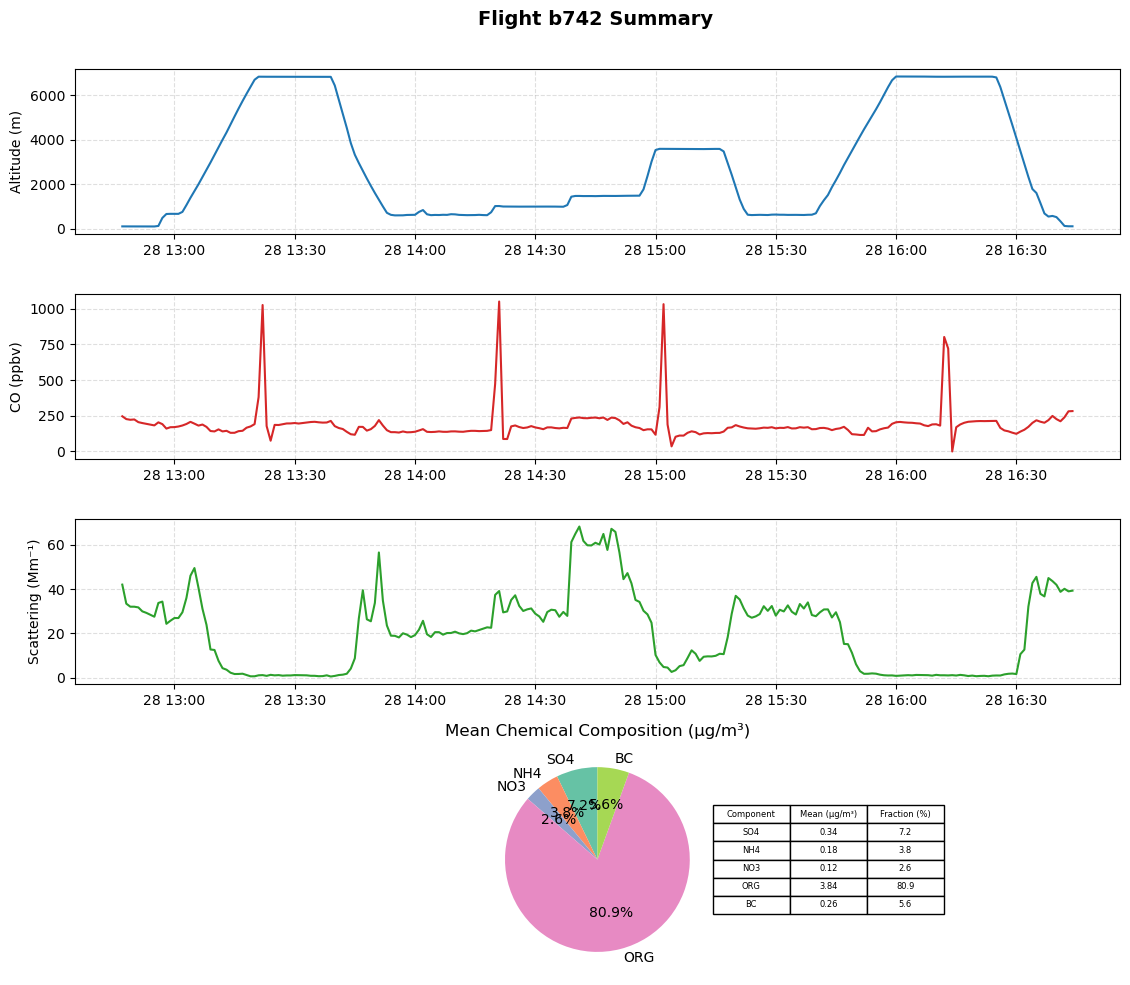

In [17]:
plot_flight_summary(df_all_one_file)

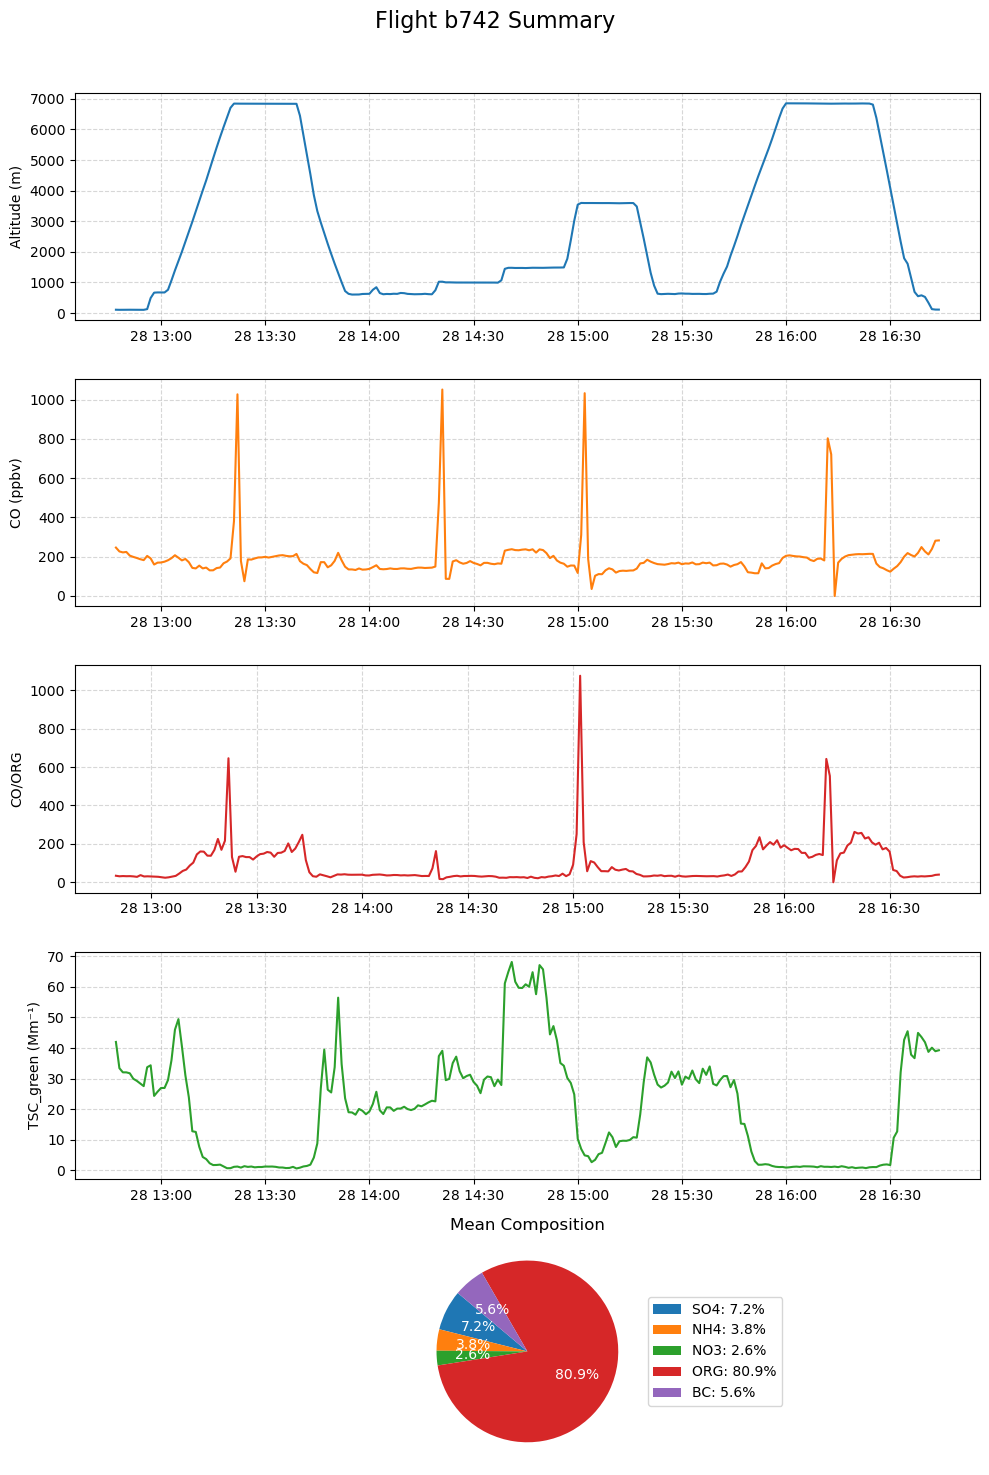


=== NNLS (unweighted) ===
R²: 0.981, Slope: 0.992
  BC: 4.4251e+01
  SO4: 7.9747e+00
  NH4: 6.9944e+00
  NO3: 2.0079e+01
  ORG: 6.7225e-01

=== Weighted LS (with SO4/NH4/NO3/ORG uncertainties) ===
R²: 0.986, Slope: 0.991
  BC: 2.8551e+01
  SO4: 1.4289e+01
  NH4: 5.3425e+00
  NO3: 1.1896e+01
  ORG: 2.1215e+00


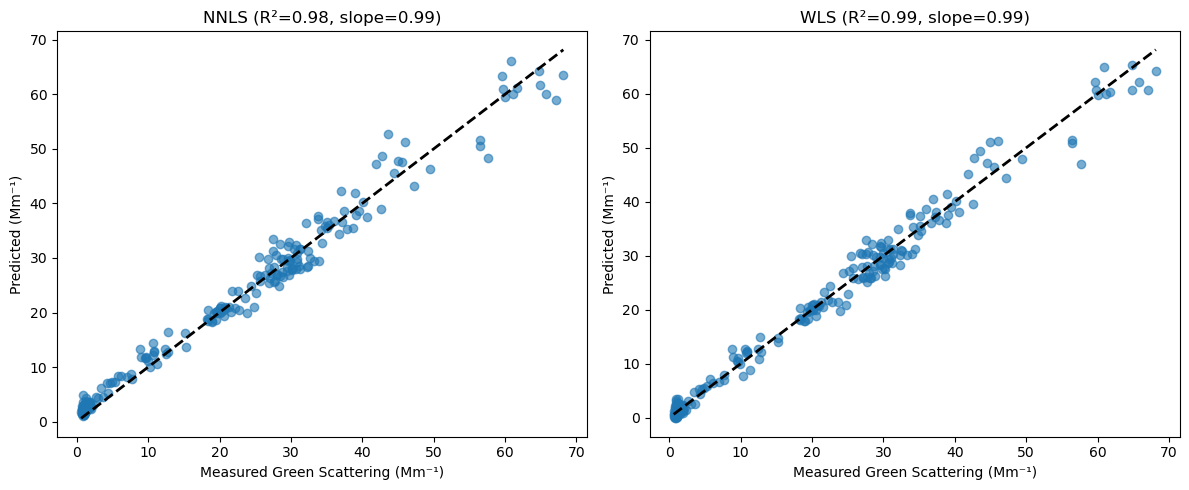

In [19]:
plot_flight_summary_and_regressions(df_all_one_file)

In [20]:
results_sct_all = []

# Iterate over all matching flights
for sp2_file, ams_file, core_file, neph_file, cloud_file in zip(filtered_sp2, filtered_ams, filtered_core, filtered_neph,filtered_cloud):
    
    ds_sp2,ds_ams,ds_neph = dataset_sp2_ams_neph(sp2_file,ams_file,neph_file)
    ds_core = xr.open_dataset(core_file)

    ds_core_cloud = xr.open_dataset(cloud_file)
    da_pcasp, times_cloud, Dgs = extract_pcasp_geo_diameter(ds_core_cloud)
    series = pd.Series(Dgs, index=pd.to_datetime(times_cloud))
    
    
    

    # Resample to 1-minute mean
    ams_resampled, sp2_resampled = file_ams_sp2_treatment(ds_sp2,ds_ams)
    resampled_neph = ds_neph.resample(datetime='1min').mean()
    resampled_core = ds_core.resample(Time='1min').mean()
    Dgs_1min = series.resample("1min").mean()
    
    
    resampled_neph_time = resampled_neph["time"].values  # Reference timestamps
    ams_resampled_time = ams_resampled["time"].values
    sp2_resampled_time = sp2_resampled["time"].values
    resampled_core_time = resampled_core["data_point"].values
    
    
    #print(f"Number of timestamps Neph: {len(resampled_neph_time)}")
    #print(f"Number of timestamps AMS: {len(ams_resampled_time)}")
    #print(f"Number of timestamps SP2: {len(sp2_resampled_time)}")
    #print(f"Number of timestamps Dg: {len(Dgs_1min)}")
    #print(f"Number of timestamps core: {len(resampled_core_time)}")
    
    # First find common times between neph and AMS
    common_times = np.intersect1d(resampled_neph_time, ams_resampled_time)
    
    # Then intersect with SP2
    common_times = np.intersect1d(common_times, sp2_resampled_time)
    # Then intersect with CORE
    common_times = np.intersect1d(common_times, resampled_core_time)
    
    #print(f"Number of common timestamps: {len(common_times)}")
    
    
    core_file_matched = resampled_core.sel(data_point=common_times)
    ams_resampled_matched = ams_resampled.sel(time=common_times)
    sp2_resampled_matched = sp2_resampled.sel(time=common_times)
    resampled_neph_matched = resampled_neph.sel(time=common_times)
    Dg_aligned_matched = Dgs_1min.reindex(pd.to_datetime(common_times), method="nearest")
    GF, RH = growth_func_calc(core_file_matched)
    
    #Core file variables
    Height = core_file_matched['GPS_ALT'].values.squeeze()
    Lon = core_file_matched['LON_GPS'].values.squeeze()
    Lat = core_file_matched['LAT_GPS'].values.squeeze()
    CO_conc_matched = core_file_matched['CO_AERO'].values.squeeze()
    PSAP_matched = core_file_matched['PSAP_LIN'].values.squeeze()
    #Neph file variables
    TSC_blue = resampled_neph_matched["TSC_BLUU"].values.squeeze()
    TSC_green = resampled_neph_matched["TSC_GRNU"].values.squeeze()
    TSC_red = resampled_neph_matched["TSC_REDU"].values.squeeze()
    #Sp2 file variables
    BC = sp2_resampled_matched.values
    #AMS file variables
    ORG = ams_resampled_matched['ORG'].values
    ORG_unc = ams_resampled_matched['ORG_uncertainty'].values
    SO4 = ams_resampled_matched['SO4'].values
    SO4_unc = ams_resampled_matched['SO4_uncertainty'].values
    NH4 = ams_resampled_matched['NH4'].values
    NH4_unc = ams_resampled_matched['NH4_uncertainty'].values
    NO3 = ams_resampled_matched['NO3'].values
    NO3_unc = ams_resampled_matched['NO3_uncertainty'].values
    
    #Secondary Inorganics
    SIC = SO4 + NH4 + NO3
    SIC_unc = np.sqrt(SO4_unc**2 + NH4_unc**2 + NO3_unc**2)
    
    
    #print('len BC:',len(BC))
    #print('len SIC:',len(SIC))
    #print('len Neph:',len(TSC_green))
    #print('len Dg:',len(Dg_aligned_matched))
    
    # Extract the flight number (b###) from the file path
    match = re.search(r'b\d{3}', core_file)  # Looks for 'b' followed by 3 digits
    flight_number = match.group(0) if match else "Unknown"
    
    results_sct_all.append({
        'ORG': ORG,
        'ORG_UNC': ORG_unc,
        'BC': BC,
        'SO4': SO4,
        'NH4': NH4,
        'NO3': NO3,
        'SO4_unc': SO4_unc,
        'NH4_unc': NH4_unc,
        'NO3_unc': NO3_unc,
        'SIC': SIC,
        'SIC_UNC': SIC_unc,
        'TSC_blue':TSC_blue,
        'TSC_green':TSC_green,
        'TSC_red':TSC_red,
        'ABS_PSAP':PSAP_matched,
        'DG_aligned': Dg_aligned_matched,
        'CO': CO_conc_matched,
        'ALT' : Height,
        'LON': Lon,
        'LAT': Lat,
        'RH': RH,
        'flight': flight_number
    })


In [21]:
# Combine all flight data
combined_data = []
for entry in results_sct_all:
    try:
        df = pd.DataFrame({
            'TSC_blue': entry['TSC_blue'],
            'TSC_green': entry['TSC_green'],
            'TSC_red': entry['TSC_red'],
            'ABS_PSAP':entry['ABS_PSAP'],
            'BC': entry['BC'],
            'SO4': entry['SO4'],
            'SIC': entry['SIC'],
            'NH4': entry['NH4'],
            'NO3': entry['NO3'],
            'SO4_UNC': entry['SO4_unc'],
            'NH4_UNC': entry['NH4_unc'],
            'NO3_UNC': entry['NO3_unc'],
            'SIC_UNC': entry['SIC_UNC'],
            'ORG': entry['ORG'],
            'ORG_UNC': entry['ORG_UNC'],
            'DG': entry['DG_aligned'],
            'ALT' : entry['ALT'],
            'LON': entry['LON'],
            'LAT': entry['LAT'],
            'CO': entry['CO'],
            'Flight': entry['flight']
        })

        combined_data.append(df)
    except Exception as e:
        print(f"Skipping flight {entry['flight']} due to error: {e}")

# Concatenate all flights
df_all = pd.concat(combined_data)

In [57]:
#df_filtered_lon_east = df_all[(df_all["DG"] > 0) & (df_all["LON"] > -53) & (df_all["ALT"] < 1500) & (df_all["CO"] > 250)]
df_all_filtered = df_all[(df_all["ALT"] < 3500) & (df_all["ALT"] > 100) & (df_all["CO"] > 200)]

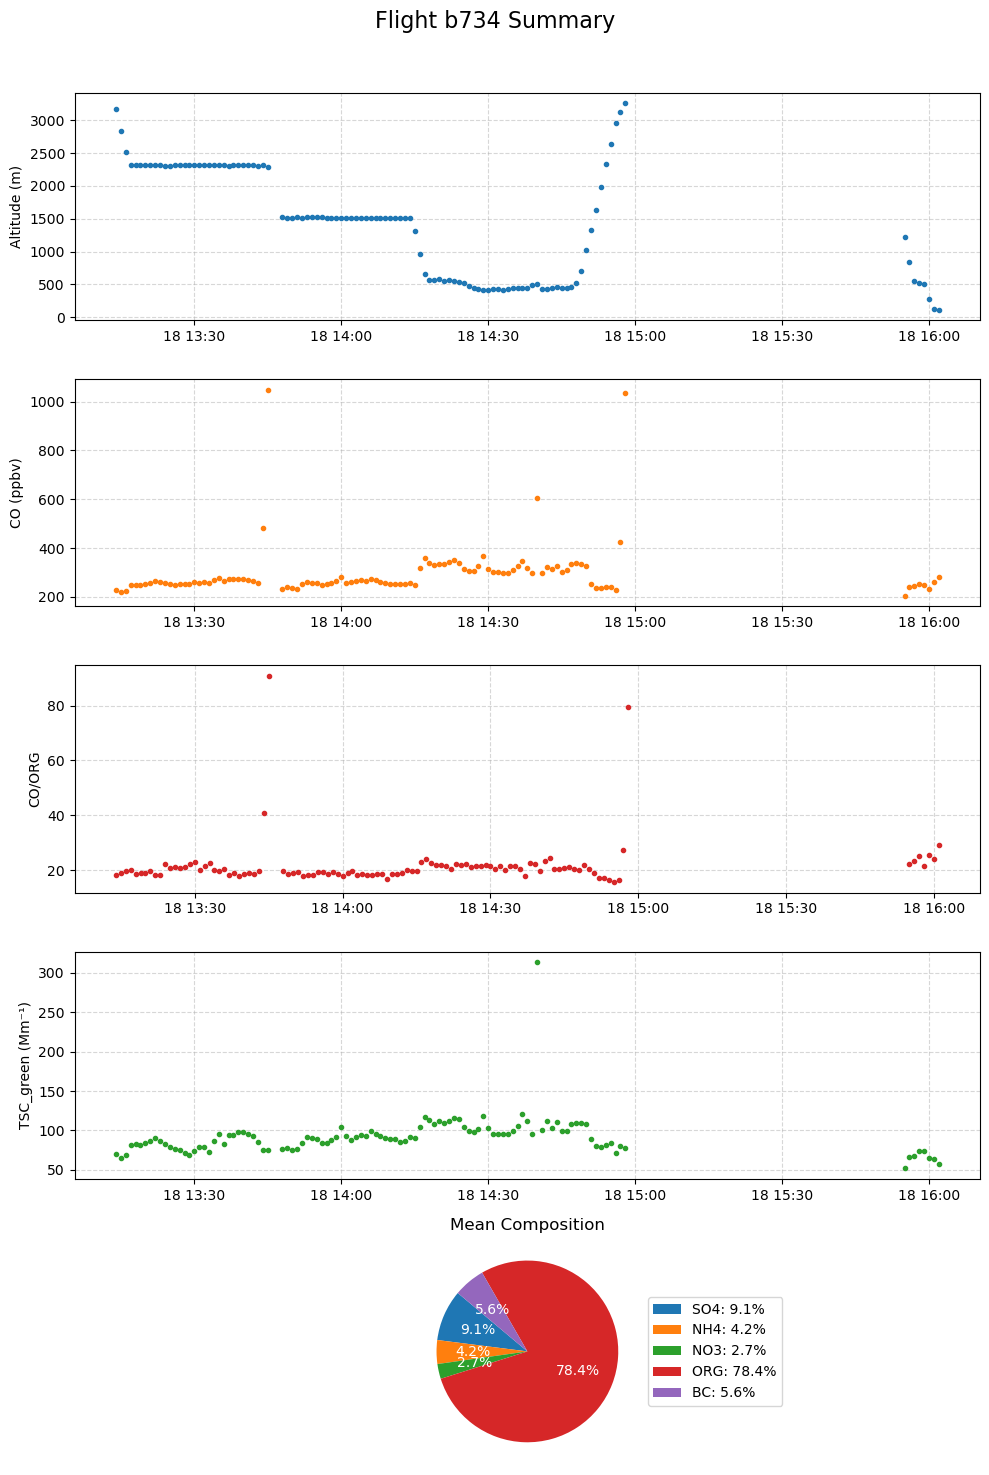


=== NNLS (unweighted) ===
R²: 0.749, Slope: 0.982
  BC: 0.0000e+00
  SO4: 0.0000e+00
  NH4: 0.0000e+00
  NO3: 0.0000e+00
  ORG: 6.7723e+00

=== Weighted LS (with SO4/NH4/NO3/ORG uncertainties) ===
R²: 0.840, Slope: 0.997
  BC: 1.4291e+01
  SO4: 0.0000e+00
  NH4: 0.0000e+00
  NO3: 0.0000e+00
  ORG: 9.8406e+00


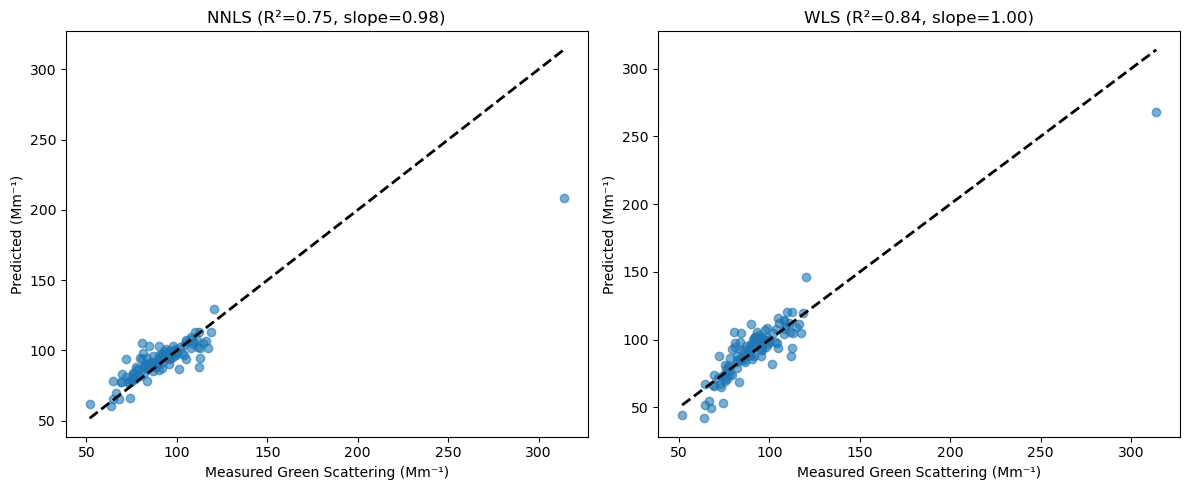

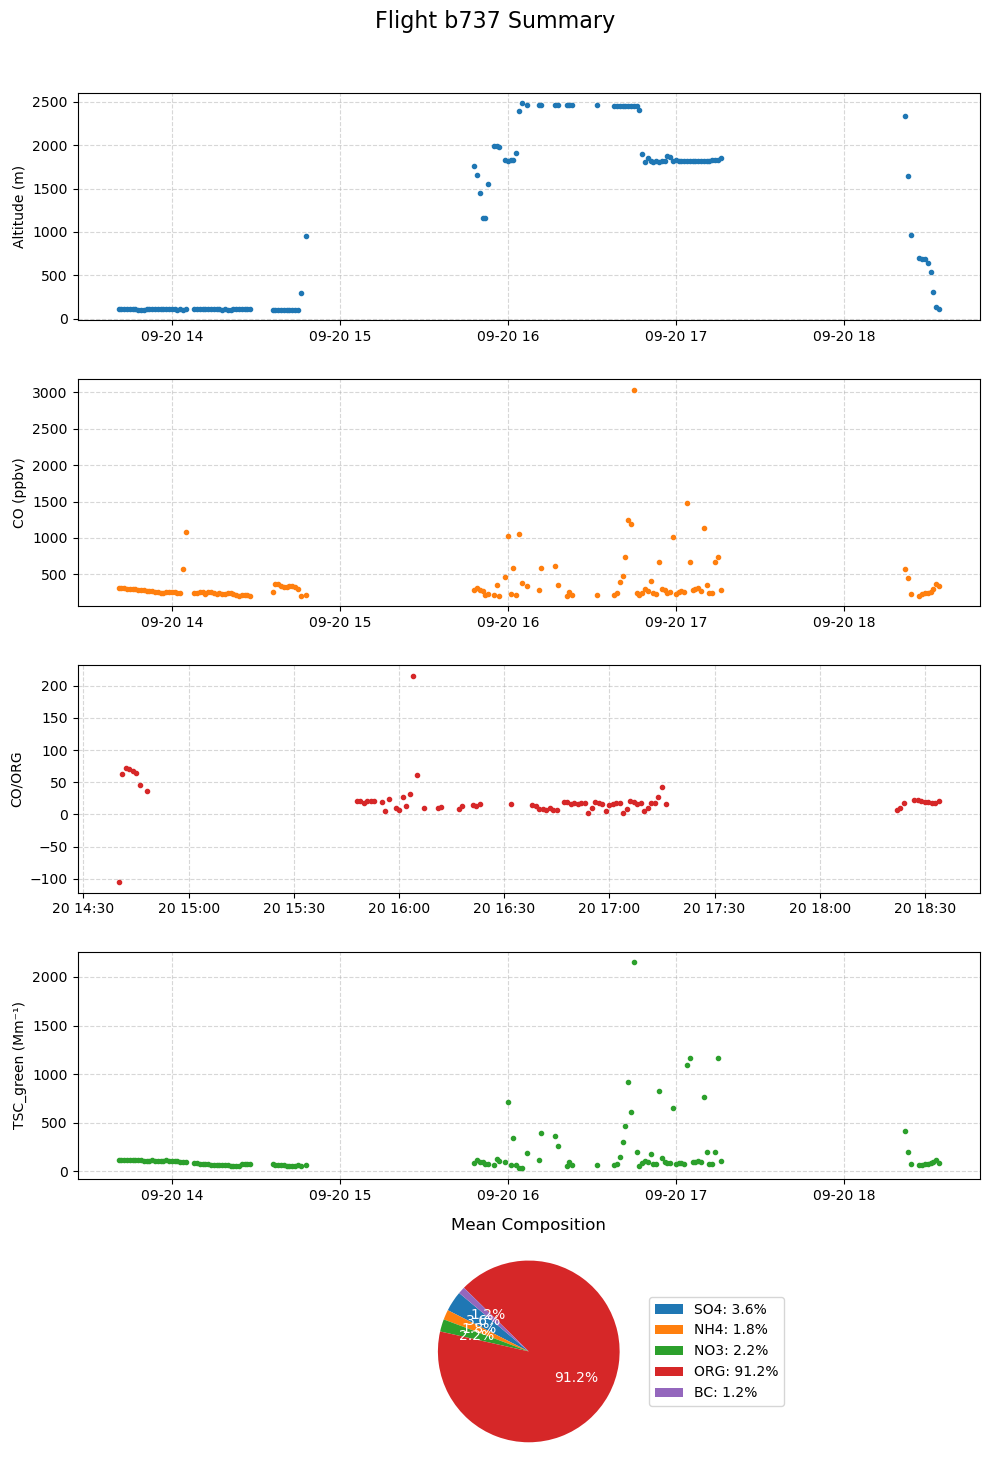


=== NNLS (unweighted) ===
R²: 0.691, Slope: 0.788
  BC: 2.9848e+01
  SO4: 6.8158e+01
  NH4: 0.0000e+00
  NO3: 0.0000e+00
  ORG: 1.8848e+00

=== Weighted LS (with SO4/NH4/NO3/ORG uncertainties) ===
R²: 0.695, Slope: 0.802
  BC: 8.0727e+01
  SO4: 7.3924e+01
  NH4: 0.0000e+00
  NO3: 0.0000e+00
  ORG: 1.9551e+00


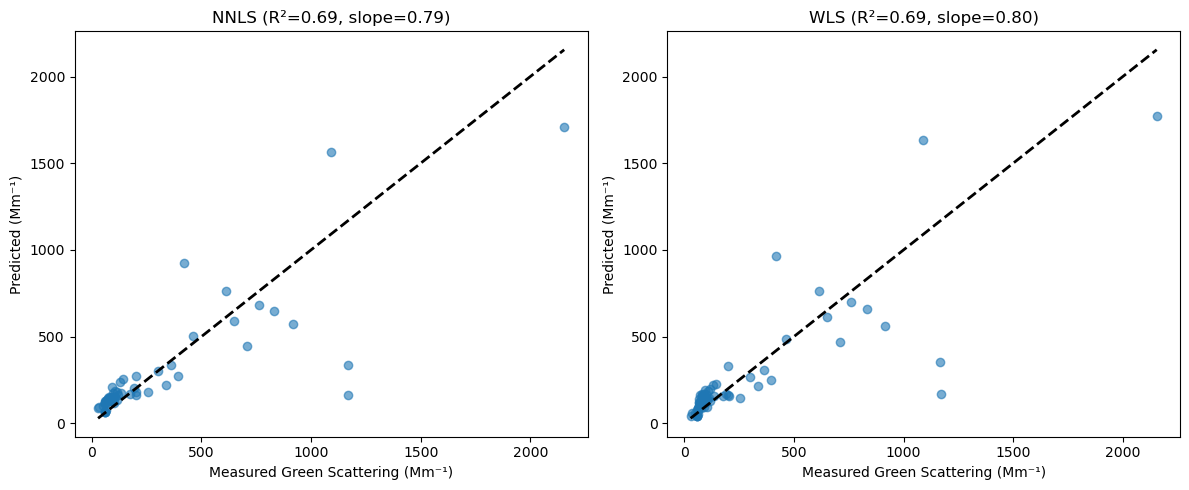

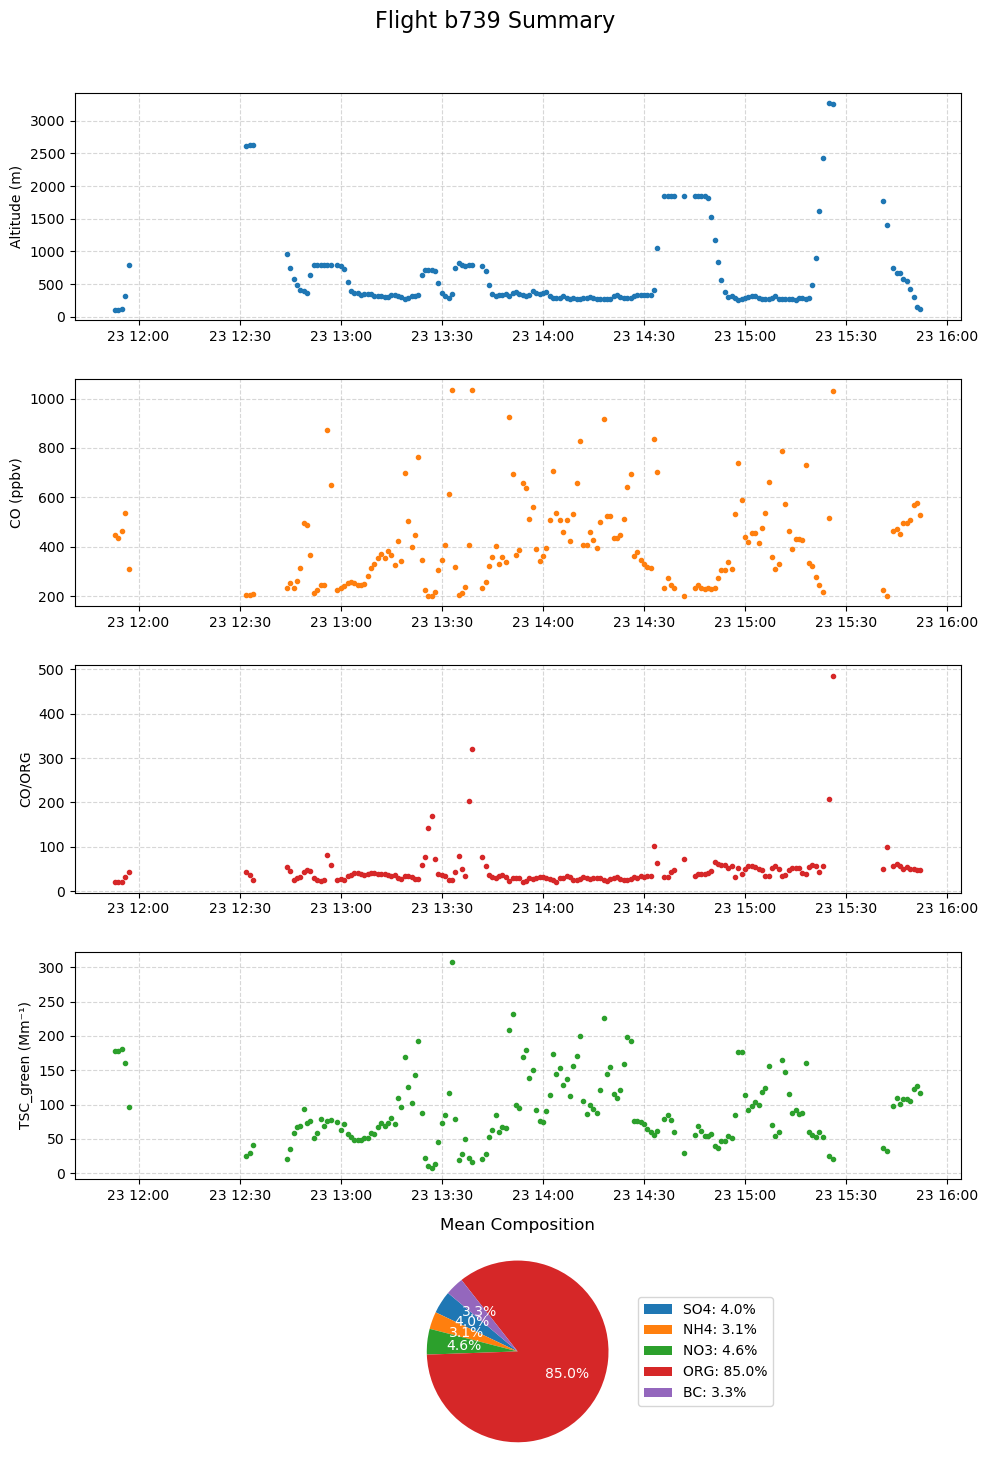


=== NNLS (unweighted) ===
R²: 0.853, Slope: 0.965
  BC: 6.6222e+01
  SO4: 0.0000e+00
  NH4: 0.0000e+00
  NO3: 9.1640e+00
  ORG: 4.8667e+00

=== Weighted LS (with SO4/NH4/NO3/ORG uncertainties) ===
R²: 0.853, Slope: 0.971
  BC: 6.9641e+01
  SO4: 0.0000e+00
  NH4: 0.0000e+00
  NO3: 7.2525e+00
  ORG: 5.0087e+00


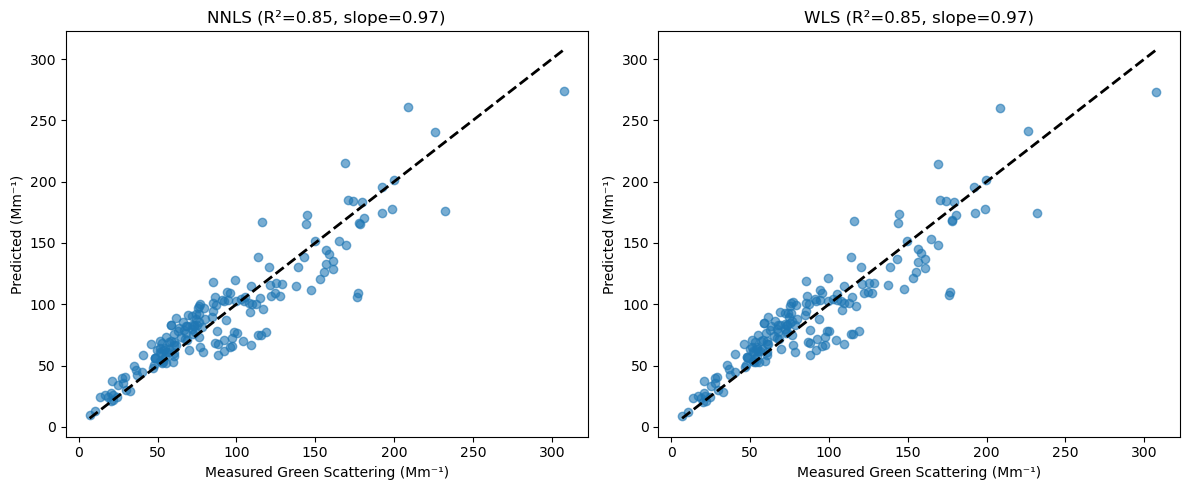

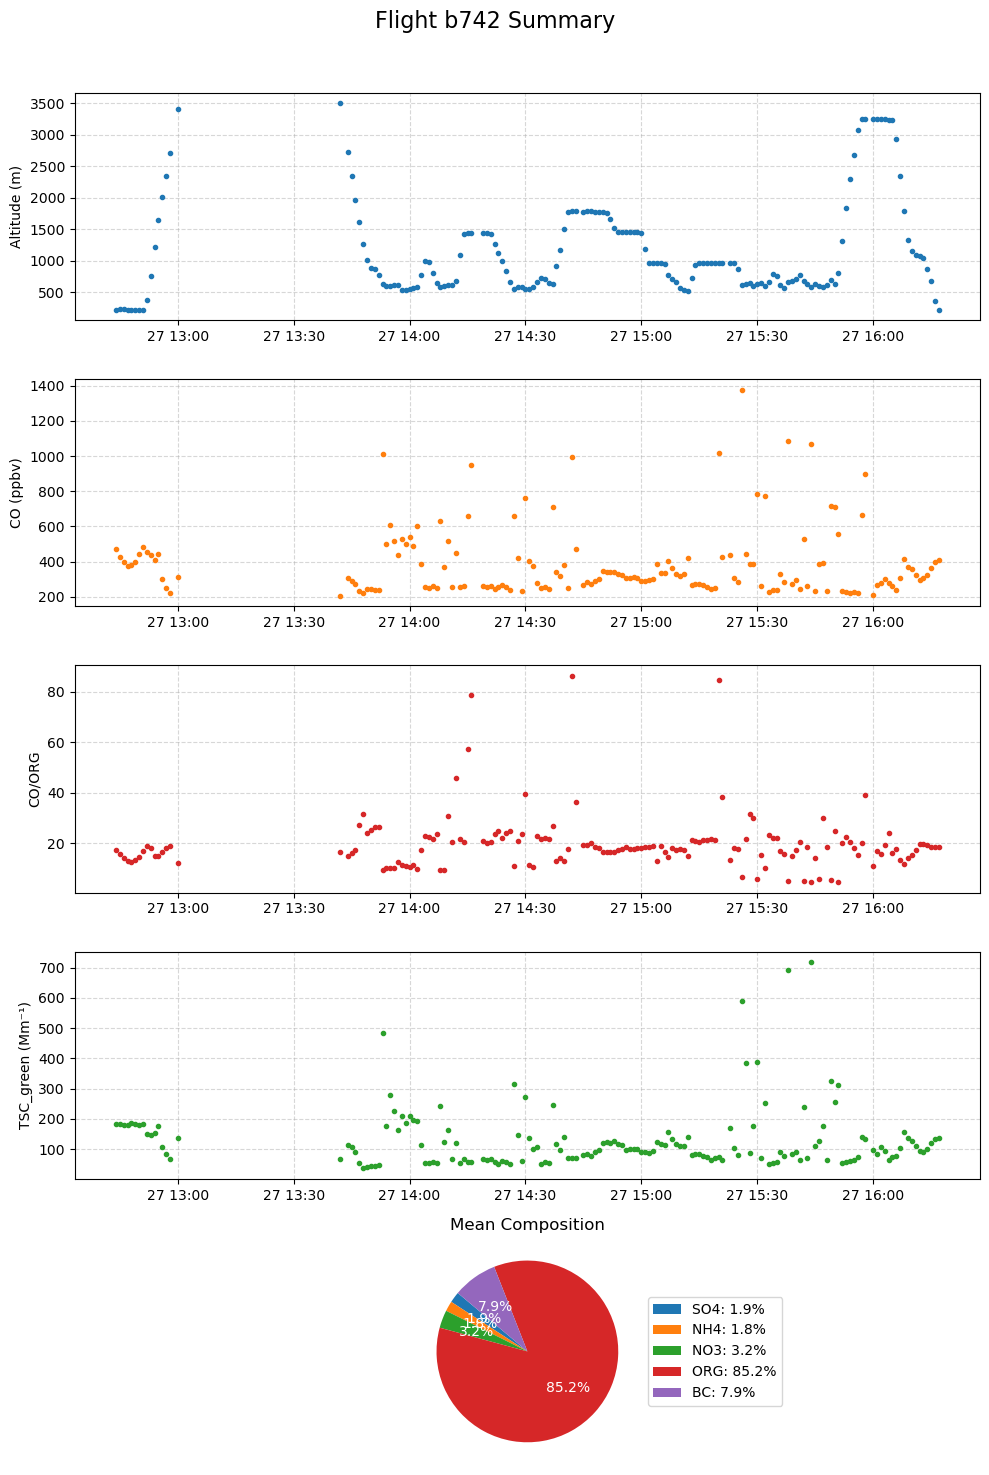


=== NNLS (unweighted) ===
R²: 0.918, Slope: 0.967
  BC: 3.0313e+01
  SO4: 1.2319e+01
  NH4: 0.0000e+00
  NO3: 0.0000e+00
  ORG: 1.4808e+00

=== Weighted LS (with SO4/NH4/NO3/ORG uncertainties) ===
R²: 0.920, Slope: 0.977
  BC: 3.0225e+01
  SO4: 0.0000e+00
  NH4: 0.0000e+00
  NO3: 0.0000e+00
  ORG: 1.4822e+00


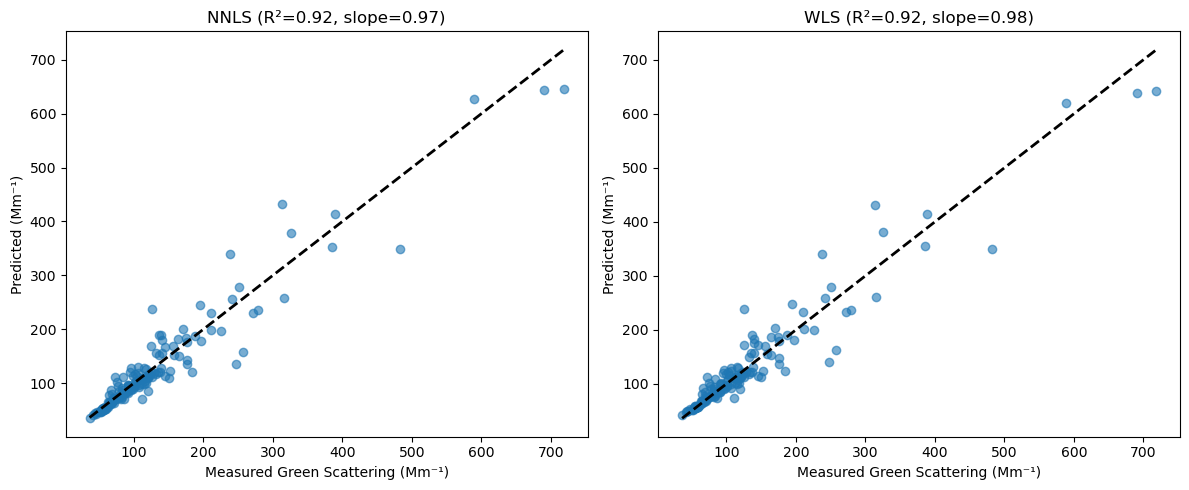

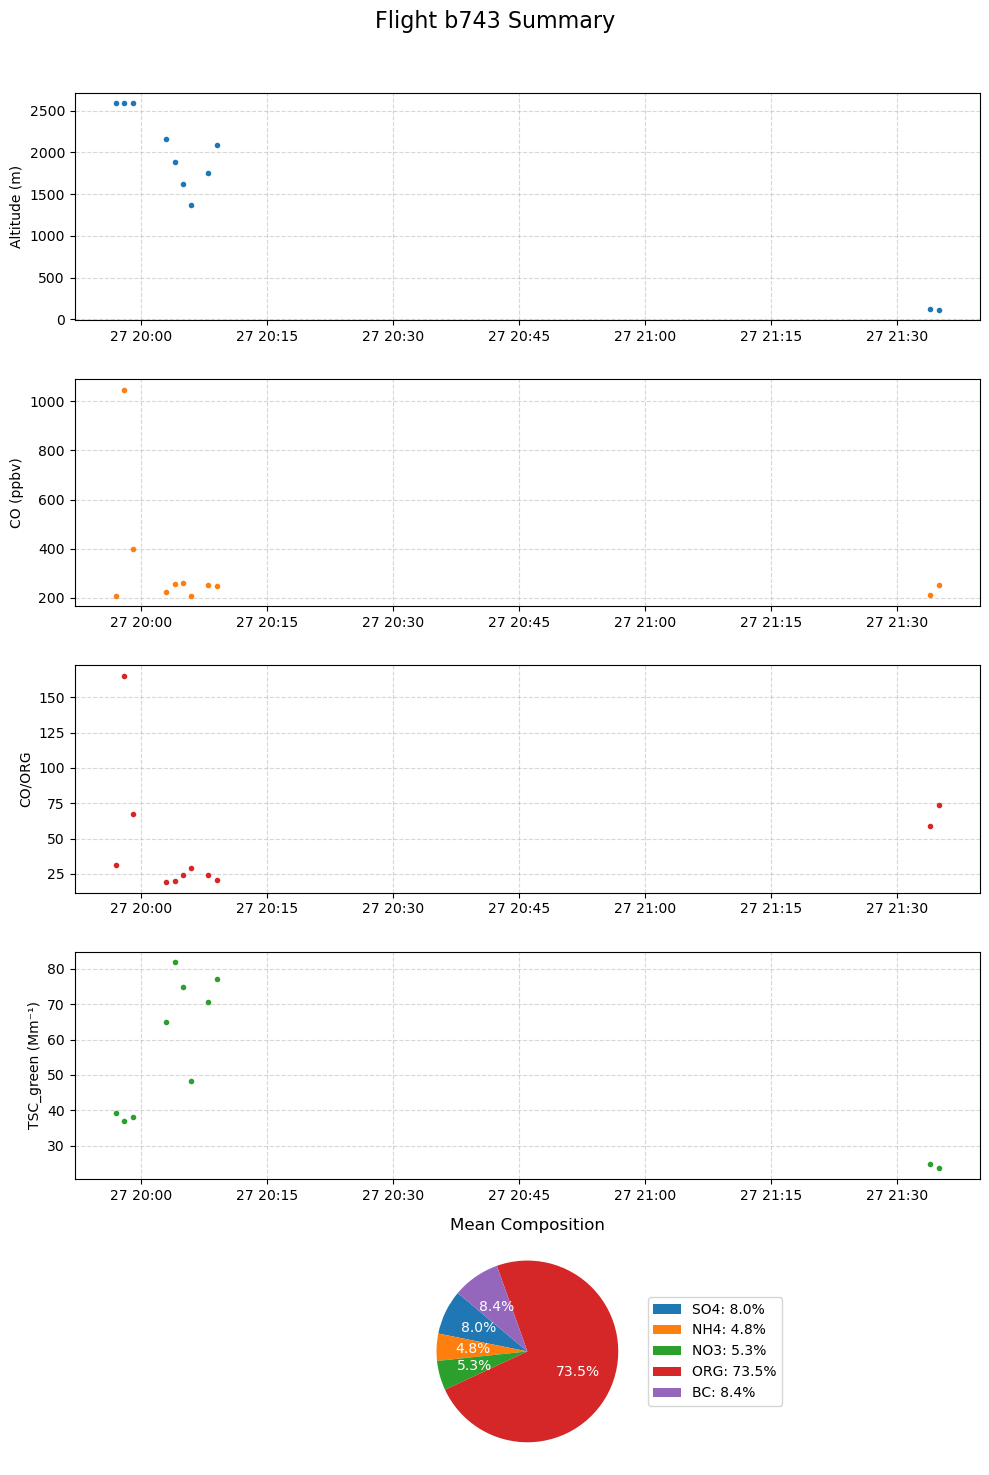


=== NNLS (unweighted) ===
R²: 0.978, Slope: 0.997
  BC: 2.6683e+01
  SO4: 0.0000e+00
  NH4: 0.0000e+00
  NO3: 0.0000e+00
  ORG: 3.3216e+00

=== Weighted LS (with SO4/NH4/NO3/ORG uncertainties) ===
R²: 0.978, Slope: 0.999
  BC: 2.4880e+01
  SO4: 0.0000e+00
  NH4: 0.0000e+00
  NO3: 0.0000e+00
  ORG: 3.4771e+00


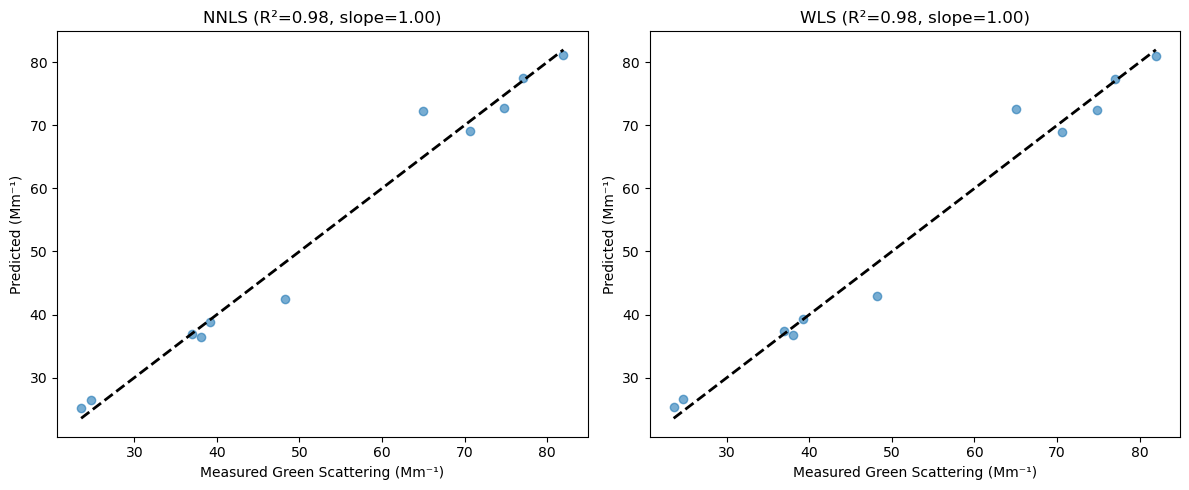

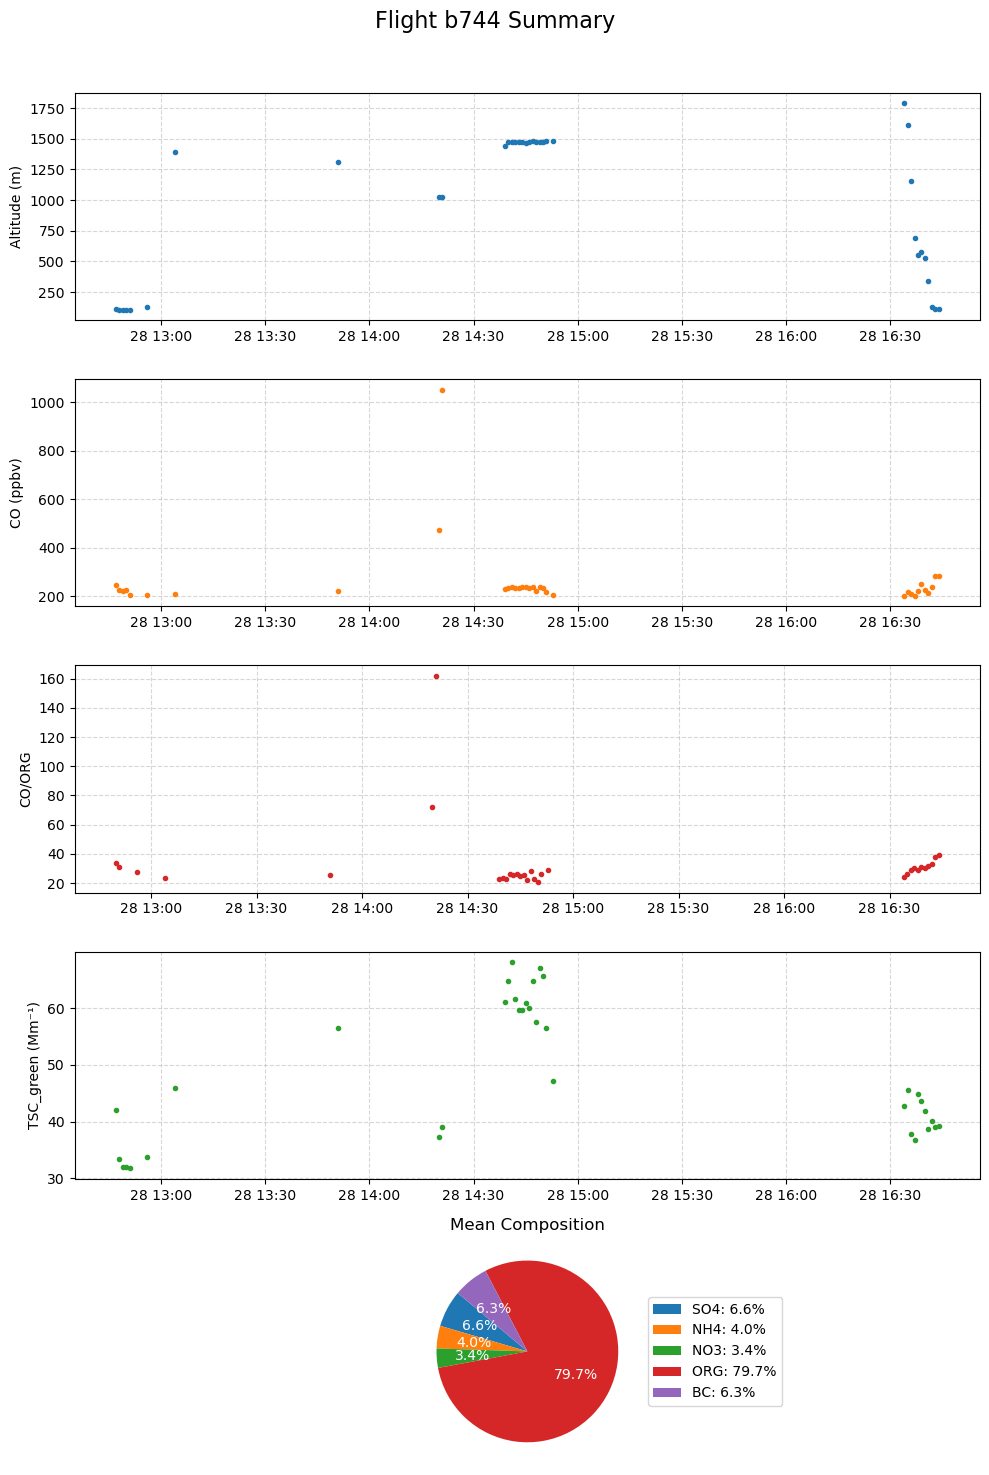


=== NNLS (unweighted) ===
R²: 0.878, Slope: 0.995
  BC: 1.8926e+01
  SO4: 1.7024e+01
  NH4: 0.0000e+00
  NO3: 1.7429e+01
  ORG: 2.3973e+00

=== Weighted LS (with SO4/NH4/NO3/ORG uncertainties) ===
R²: 0.881, Slope: 0.990
  BC: 1.7983e+01
  SO4: 1.6054e+01
  NH4: 0.0000e+00
  NO3: 1.2815e+01
  ORG: 3.4439e+00


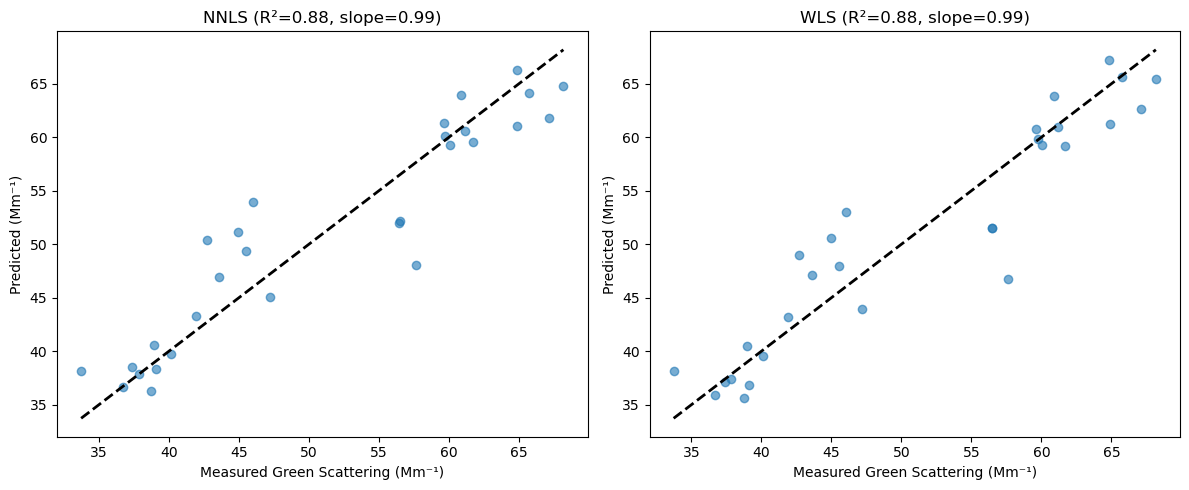

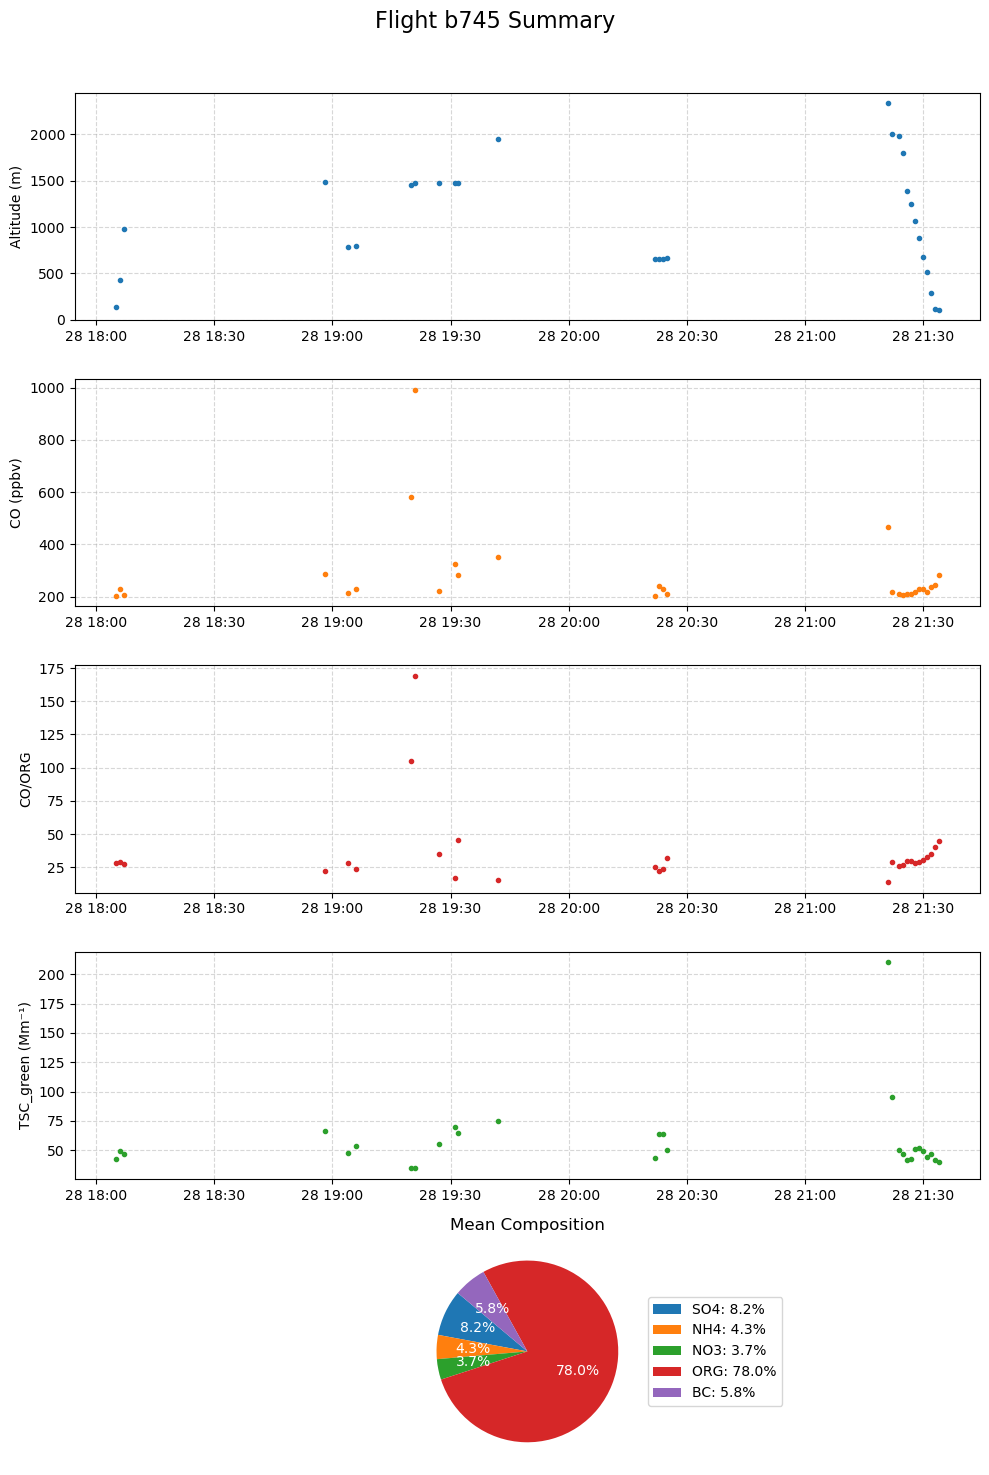


=== NNLS (unweighted) ===
R²: 0.839, Slope: 0.963
  BC: 3.4217e+01
  SO4: 1.0956e+01
  NH4: 0.0000e+00
  NO3: 0.0000e+00
  ORG: 2.2089e+00

=== Weighted LS (with SO4/NH4/NO3/ORG uncertainties) ===
R²: 0.869, Slope: 0.973
  BC: 8.5057e+00
  SO4: 1.2006e+01
  NH4: 0.0000e+00
  NO3: 8.9172e+00
  ORG: 1.4812e+00


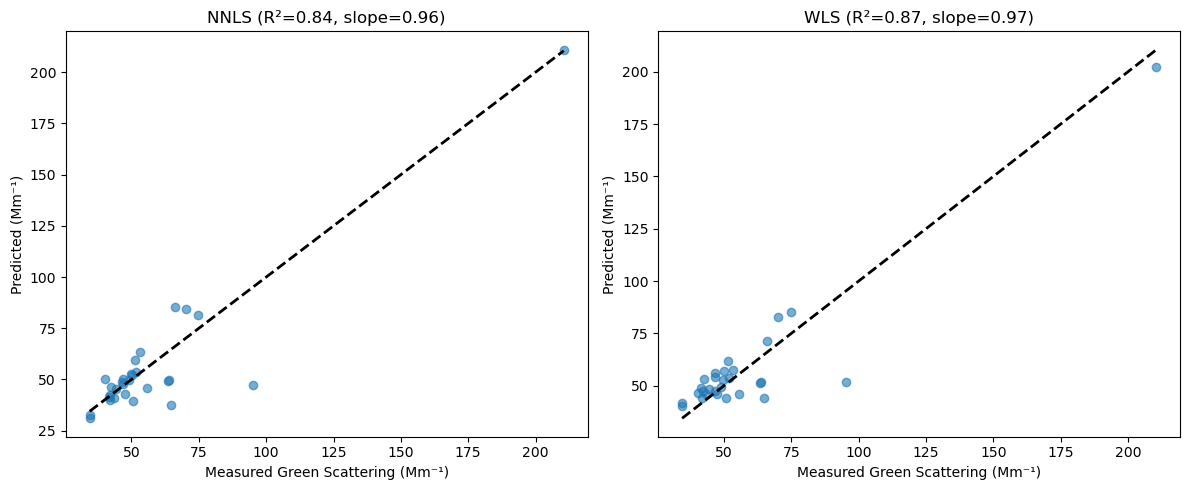

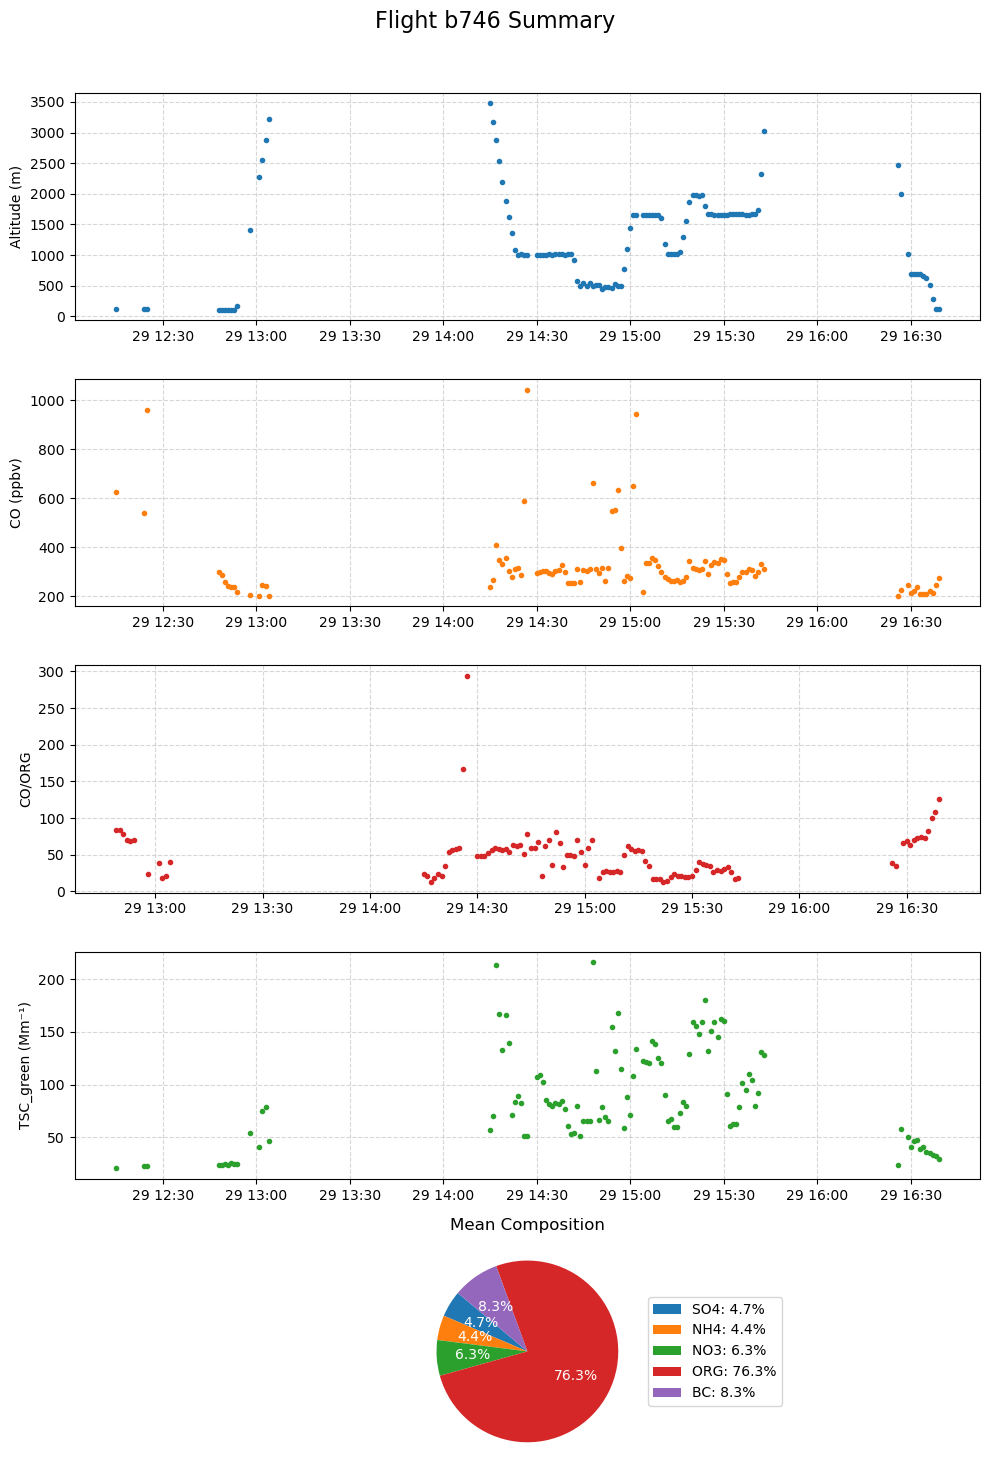


=== NNLS (unweighted) ===
R²: 0.836, Slope: 0.970
  BC: 6.1923e+01
  SO4: 0.0000e+00
  NH4: 0.0000e+00
  NO3: 0.0000e+00
  ORG: 3.4392e+00

=== Weighted LS (with SO4/NH4/NO3/ORG uncertainties) ===
R²: 0.841, Slope: 0.980
  BC: 4.4694e+01
  SO4: 0.0000e+00
  NH4: 0.0000e+00
  NO3: 0.0000e+00
  ORG: 4.0980e+00


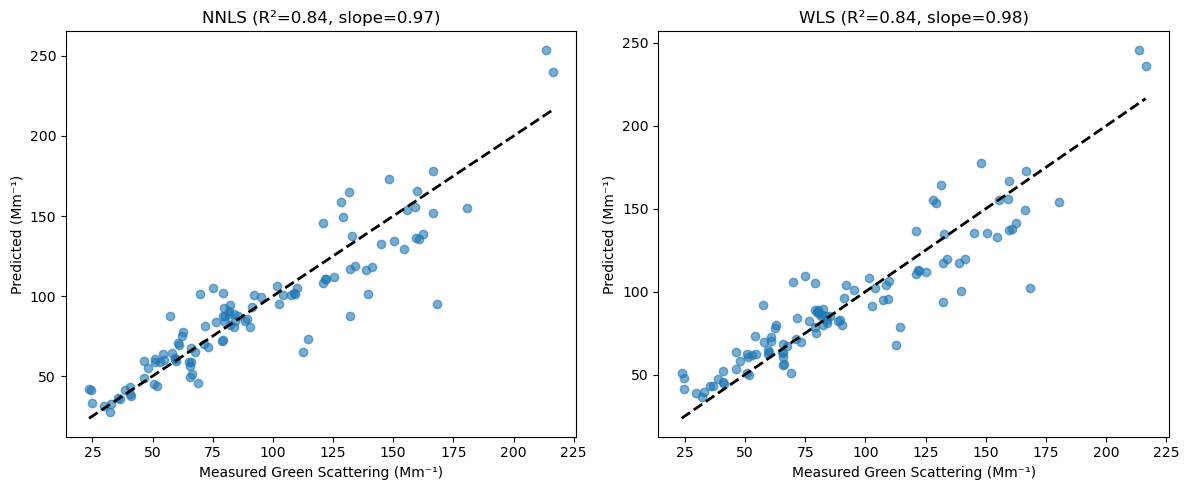

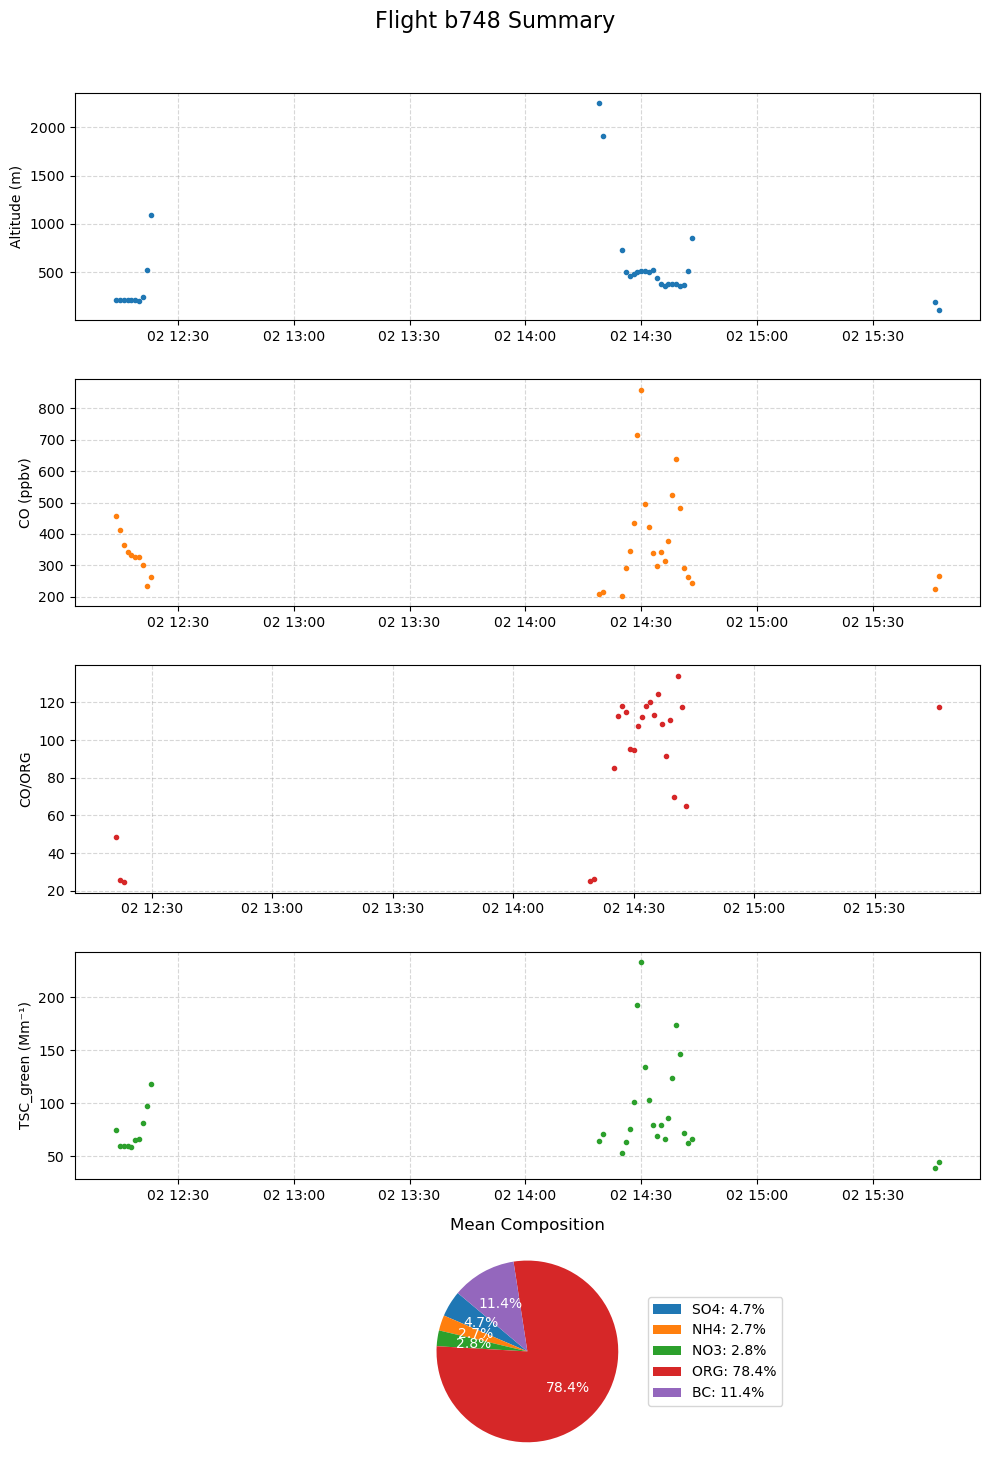


=== NNLS (unweighted) ===
R²: 0.068, Slope: 0.832
  BC: 0.0000e+00
  SO4: 0.0000e+00
  NH4: 0.0000e+00
  NO3: 0.0000e+00
  ORG: 1.7816e+01

=== Weighted LS (with SO4/NH4/NO3/ORG uncertainties) ===
R²: 0.292, Slope: 0.927
  BC: 0.0000e+00
  SO4: 0.0000e+00
  NH4: 0.0000e+00
  NO3: 0.0000e+00
  ORG: 1.2720e+01


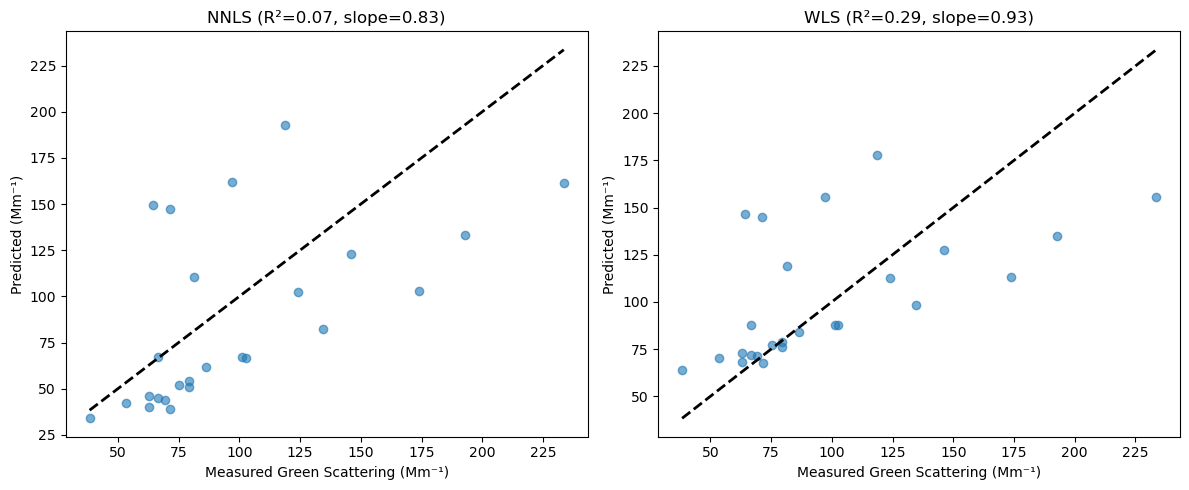

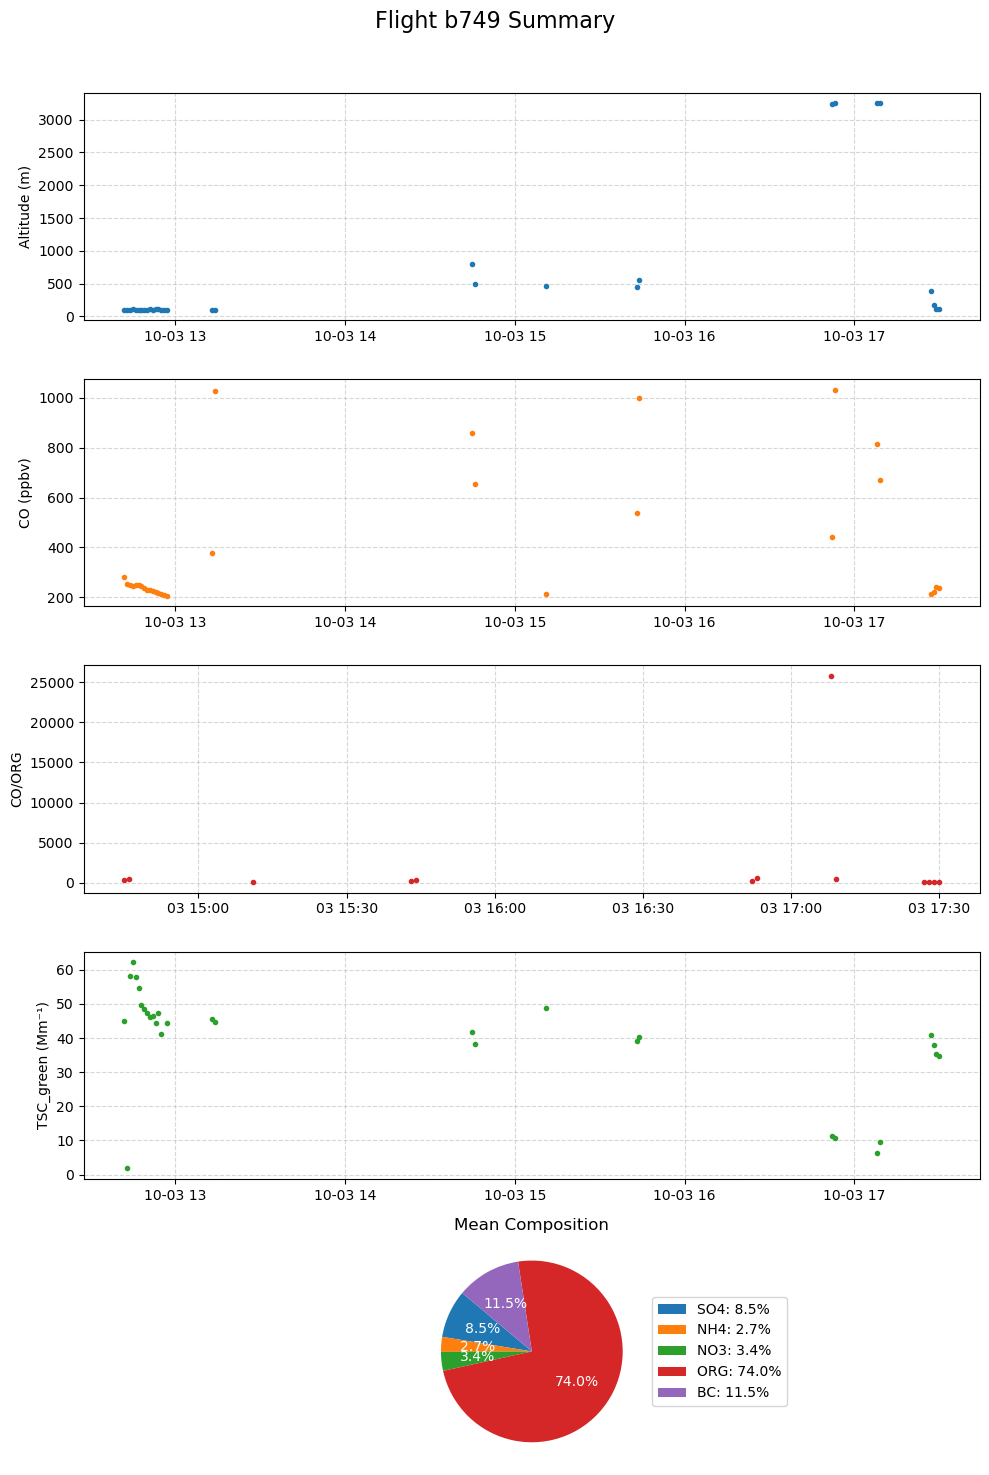


=== NNLS (unweighted) ===
R²: 0.603, Slope: 0.928
  BC: 4.5309e+01
  SO4: 5.6206e+01
  NH4: 0.0000e+00
  NO3: 0.0000e+00
  ORG: 0.0000e+00

=== Weighted LS (with SO4/NH4/NO3/ORG uncertainties) ===
R²: 0.612, Slope: 0.928
  BC: 4.0419e+01
  SO4: 3.8462e+01
  NH4: 0.0000e+00
  NO3: 0.0000e+00
  ORG: 0.0000e+00


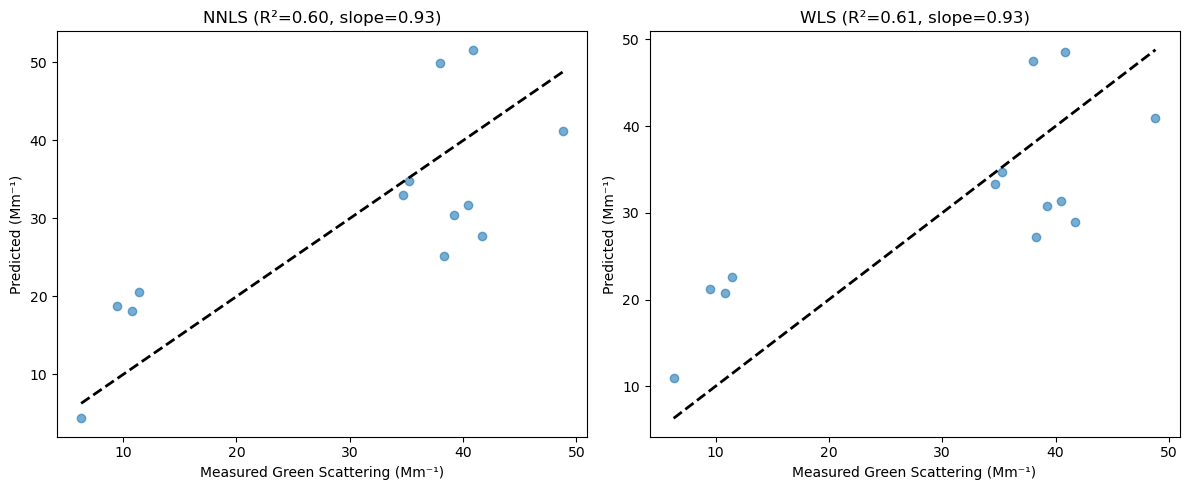

In [58]:
results_MLR = plot_flight_summary_and_regressions(df_all_filtered)

In [59]:
def MLR_result_all_flights(df_all):
    result_MLR_all_flights = []
    # =======================================================
    # === Regression plots (NNLS and WLS) for all flights ===
    # =======================================================
    df_reg = df_all[[
        'TSC_green', 'BC', 'SO4', 'NH4', 'NO3', 'ORG',
        'SO4_UNC', 'NH4_UNC', 'NO3_UNC', 'ORG_UNC'
    ]].replace([np.inf, -np.inf], np.nan).dropna()
    
    X = df_reg[['BC', 'SO4', 'NH4', 'NO3', 'ORG']].values
    y = df_reg['TSC_green'].values * 1e6
    
    # --- NNLS (Non-negative least squares)
    coeffs_nnls, _ = nnls(X, y)
    y_pred_nnls = X @ coeffs_nnls
    r2_nnls = r2_score(y, y_pred_nnls)
    slope_nnls = np.sum(y * y_pred_nnls) / np.sum(y * y)
    
    # --- Weighted LS (with uncertainties)
    sigma = np.sqrt(
        df_reg['SO4_UNC']**2 +
        df_reg['NH4_UNC']**2 +
        df_reg['NO3_UNC']**2 +
        df_reg['ORG_UNC']**2
    ).values
    weights = 1.0 / (sigma + 1e-12)
    
    wls = LinearRegression(positive=True)
    wls.fit(X, y, sample_weight=weights)
    coeffs_wls = wls.coef_
    y_pred_wls = wls.predict(X)
    r2_wls = r2_score(y, y_pred_wls)
    slope_wls = np.sum(y * y_pred_wls) / np.sum(y * y)
    
    # --- Print results
    print("\n=== NNLS (unweighted) ===")
    print(f"R²: {r2_nnls:.3f}, Slope: {slope_nnls:.3f}")
    for var, coef in zip(['BC','SO4','NH4','NO3','ORG'], coeffs_nnls):
        print(f"  {var}: {coef:.4e}")
    
    print("\n=== Weighted LS (with SO4/NH4/NO3/ORG uncertainties) ===")
    print(f"R²: {r2_wls:.3f}, Slope: {slope_wls:.3f}")
    for var, coef in zip(['BC','SO4','NH4','NO3','ORG'], coeffs_wls):
        print(f"  {var}: {coef:.4e}")
    
    # Store results
    result_MLR_all_flights.append({
        'Flight': 'All_flights',
        'R2_NNLS': r2_nnls,
        'Slope_NNLS': slope_nnls,
        **{f'Coef_{v}_NNLS': c for v, c in zip(['BC','SO4','NH4','NO3','ORG'], coeffs_nnls)},
        'R2_WLS': r2_wls,
        'Slope_WLS': slope_wls,
        **{f'Coef_{v}_WLS': c for v, c in zip(['BC','SO4','NH4','NO3','ORG'], coeffs_wls)}
    })
    
    
    # --- Plot regression comparison
    plt.figure(figsize=(12,5))
    
    # Left: NNLS
    plt.subplot(1,2,1)
    plt.scatter(y, y_pred_nnls, alpha=0.6)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
    plt.xlabel("Measured Green Scattering (Mm⁻¹)")
    plt.ylabel("Predicted (Mm⁻¹)")
    plt.title(f"NNLS (R²={r2_nnls:.2f}, slope={slope_nnls:.2f})")
    
    # Right: WLS
    plt.subplot(1,2,2)
    plt.scatter(y, y_pred_wls, alpha=0.6)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
    plt.xlabel("Measured Green Scattering (Mm⁻¹)")
    plt.ylabel("Predicted (Mm⁻¹)")
    plt.title(f"WLS (R²={r2_wls:.2f}, slope={slope_wls:.2f})")
    
    plt.tight_layout()
    plt.show()
    return result_MLR_all_flights


=== NNLS (unweighted) ===
R²: 0.698, Slope: 0.818
  BC: 1.3429e+01
  SO4: 4.2292e+01
  NH4: 0.0000e+00
  NO3: 1.8945e+01
  ORG: 2.0273e+00

=== Weighted LS (with SO4/NH4/NO3/ORG uncertainties) ===
R²: 0.702, Slope: 0.830
  BC: 7.2876e+00
  SO4: 2.1917e+01
  NH4: 0.0000e+00
  NO3: 1.8695e+01
  ORG: 2.2689e+00


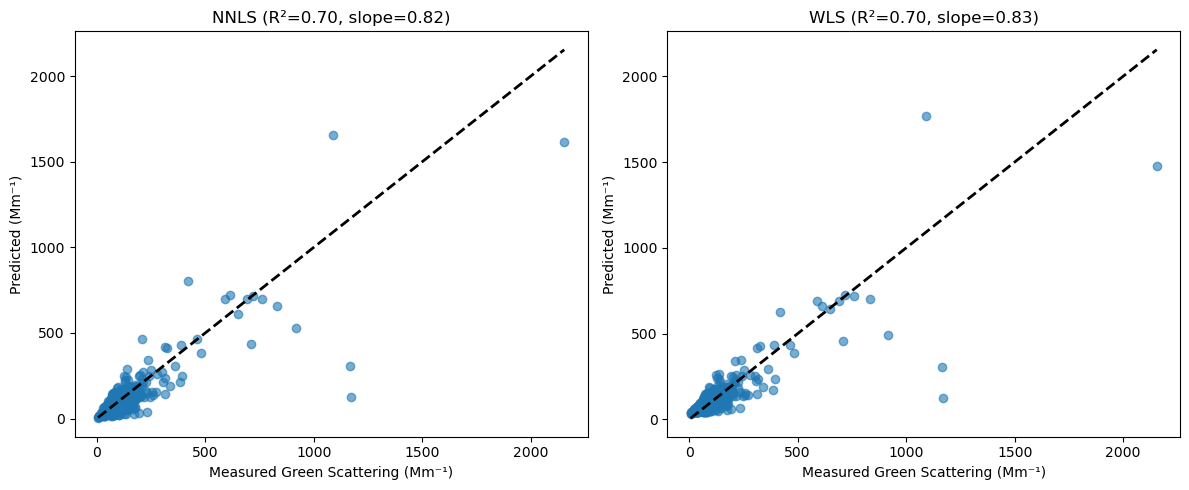

In [60]:
result_MLR_all_flights = MLR_result_all_flights(df_all_filtered)

In [61]:
df_summary = pd.DataFrame(results_MLR)

# Append the "All_flights" result
if isinstance(result_MLR_all_flights, list) and len(result_MLR_all_flights) > 0:
    df_summary = pd.concat(
        [df_summary, pd.DataFrame(result_MLR_all_flights)],
        ignore_index=True
    )
    
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

In [62]:
# Save to CSV
output_path = "flight_regression_summary_filter1.csv"
df_summary.to_csv(output_path, index=False)

print(f"\n✅ Summary table saved to: {output_path}")


✅ Summary table saved to: flight_regression_summary_filter1.csv
